<div style="font-family:'Georgia','Times New Roman',Times,serif; width:80%; margin:20px auto; padding:10px 20px 20px 20px; background:#ffffff; border-left:20px solid #003366; box-shadow:0 5px 20px rgba(0,0,0,0.1); text-align:center; border-radius:8px;">

  <div style="display:flex; align-items:center; justify-content:center; gap:20px; margin-bottom:15px; padding-bottom:1px; border-bottom:2px solid #eeeeee;">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" style="max-width:80px; height:auto;">
    <div style="font-size:1.1em; color:#003366; font-weight:bold; text-align:left;">Universidad Nacional de Colombia</div>
  </div>

  <h1 style="color:#003366; font-size:2.2em; margin:0.6em 0; font-weight:bold; line-height:1.2;">Detección de enfermedades en plantas de maí­z y frí­jol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2 style="color:#444444; font-size:1.4em; margin-bottom:0.8em; font-weight:normal; font-style:italic;">Análisis exploratorio de datos y entrenamiento de modelos de aprendizaje de máquina con datos de frí­jol</h2>

  <div style="margin-bottom:0em; font-size:1.1em; color:#222222;">
    <p style="text-align:center; margin:0;"><strong>Autor:</strong> Selene Solano Vera</p>
  </div>

  <div style="margin:1.0em 0 1.0em 0; padding:0.8em 0; color:#666666; font-size:1em;">Medellí­n, Febrero de 2026</div>

  <div style="height:0.1rem;"></div>

</div>


# Utilidades y Configuración Inicial

Esta sección incluye la importación de bibliotecas necesarias y la configuración del entorno de trabajo para el análisis exploratorio de datos y el entrenamiento de modelos de aprendizaje automático.

## Importar librerí­as

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, ConfusionMatrixDisplay
import warnings
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import math
import os
import pickle
from datetime import datetime
import time

## Configurar estilo de visualización

In [ ]:
# Configuración del tema visual de seaborn
sns.set_theme(style="whitegrid", palette="viridis")

# Configuración de parámetros globales de matplotlib
plt.rcParams['figure.figsize'] = (12, 7)    # Tamaí±o de figura predeterminado (ancho, alto) en pulgadas
plt.rcParams['axes.titlesize'] = 18         # Tamaí±o de fuente para tí­tulos de gráficos
plt.rcParams['axes.labelsize'] = 14         # Tamaí±o de fuente para etiquetas de ejes

# Suprimir advertencias para mantener limpia la salida del notebook
warnings.filterwarnings('ignore')

# 1. Definición del Problema y Recopilación de Datos

**Pregunta de Investigación:** ¿Es posible determinar el nivel de deficiencia de fósforo en plantas de frí­jol mediante el análisis de la intensidad de reflectancia en imágenes multiespectrales?

**Hipótesis:** Las plantas con diferentes niveles de deficiencia de fósforo presentarán patrones distintivos en su reflectancia espectral que permitirán su clasificación automática.

**Descripción de los datos**

- Variable Objetivo:

    - Tratamiento 1: 25% de la dosis óptima de fósforo (deficiencia severa)
    - Tratamiento 2: 50% de la dosis óptima de fósforo (deficiencia moderada)
    - Tratamiento 3: 75% de la dosis óptima de fósforo (deficiencia leve)
    - Tratamiento 4: 100% de la dosis óptima de fósforo (control saludable)

- Variables Predictoras:

    - `pixel_relativo_x/y`: Coordenadas relativas al centroide de la planta
    - `intensidad`: Valor de reflectancia espectral
    - `genotipo`: Identificador del genotipo (1-8)
    - `banda`: Banda espectral de captura

**Fuente y recopilación de los datos**

Se cuenta con un conjunto de imágenes multiespectrales, las cuales fueron desagregadas por bandas para su posterior procesamiento. De cada banda se extrajeron los valores correspondientes a la intensidad y a los pí­xeles relativos. La definición de cada banda se encuentra asociada a la separación de los canales espectrales, cuyos valores están previamente determinados por el sensor de adquisición. Finalmente, la identificación del genotipo se realizó mediante la aplicación de una máscara sobre la imagen.

# 2. Carga y Primera Inspección de Datos

## 2.1. Leer datos de frí­jol

Se cargan los datos preprocesados de imágenes multiespectrales de plantas de frijol. El dataset contiene información sobre pí­xeles extraí­dos de diferentes bandas espectrales, con sus respectivas coordenadas relativas e intensidades de reflectancia.

In [ ]:
# Carga del dataset v4 (split por objeto)
data_train = pd.read_csv("datasets/dataset_frijol_fix_obj_train.csv")
data_test = pd.read_csv("datasets/dataset_frijol_fix_obj_test.csv")

# Se concatena solo para analisis exploratorio
data = pd.concat([data_train, data_test], ignore_index=True)

# Columnas espectrales en formato ancho
band_cols = sorted([c for c in data.columns if c.startswith("int_")], key=lambda x: int(x.split("_")[1]))
if len(band_cols) == 0:
    raise ValueError("No se encontraron columnas espectrales int_*. Verifica el dataset v4.")

# Utilidad para construir muestra en formato largo por banda sin explotar memoria
def sample_long_by_band(df, band_columns, n=50000, seed=42):
    n = min(n, len(df))
    sampled = df.sample(n=n, random_state=seed)
    return sampled.melt(
        id_vars=["pixel_relativo_x", "pixel_relativo_y", "genotipo", "tratamiento"],
        value_vars=band_columns,
        var_name="banda",
        value_name="intensidad",
    )

print(f"Bandas detectadas ({len(band_cols)}): {band_cols}")

Bandas detectadas (10): ['int_444', 'int_475', 'int_531', 'int_560', 'int_650', 'int_668', 'int_705', 'int_717', 'int_740', 'int_848']


## 2.2. Exploración inicial de los datos

Esta fase comprende un análisis preliminar del dataset para entender su estructura, identificar las variables disponibles, detectar valores faltantes o inconsistentes, y obtener estadí­sticas descriptivas básicas.

In [ ]:
# Visualización de las primeras filas del dataset
data.head()

,pixel_relativo_x,pixel_relativo_y,genotipo,tratamiento,object_id,split,int_444,int_475,int_531,int_560,int_650,int_668,int_705,int_717,int_740,int_848
0,8.1,-29.81,5,2,REF__0000_T2R1__obj_003,train,1,1,4,5,2,2,6,11,20,23
1,9.1,-29.81,5,2,REF__0000_T2R1__obj_003,train,1,1,5,5,1,2,6,11,21,22
2,10.1,-29.81,5,2,REF__0000_T2R1__obj_003,train,1,2,4,5,1,2,6,12,21,23
3,7.1,-28.81,5,2,REF__0000_T2R1__obj_003,train,1,1,4,4,2,2,6,13,21,21
4,8.1,-28.81,5,2,REF__0000_T2R1__obj_003,train,1,1,4,5,2,2,6,12,21,23


In [ ]:
# Visualización de las últimas filas del dataset
data.tail()

,pixel_relativo_x,pixel_relativo_y,genotipo,tratamiento,object_id,split,int_444,int_475,int_531,int_560,int_650,int_668,int_705,int_717,int_740,int_848
329840,2.28,12.42,5,4,REF__0017_T4R3__obj_031,test,2,2,5,5,2,2,8,12,19,19
329841,3.28,12.42,5,4,REF__0017_T4R3__obj_031,test,2,2,5,6,3,3,9,14,20,19
329842,4.28,12.42,5,4,REF__0017_T4R3__obj_031,test,1,1,5,6,2,2,9,13,19,20
329843,5.28,12.42,5,4,REF__0017_T4R3__obj_031,test,1,1,4,5,1,2,8,12,17,17
329844,6.28,12.42,5,4,REF__0017_T4R3__obj_031,test,1,1,4,5,2,2,8,9,16,17


**Dimensiones del dataset**

In [ ]:
# Dimensiones del dataset: (número de filas, número de columnas)
print(f"Tamaí±o del dataset: {data.shape}")

TamaÃ±o del dataset: (329845, 16)


In [9]:
# Nombres de las columnas del dataset
print(f"Columnas:\n {data.columns}")

Columnas:
 Index(['pixel_relativo_x', 'pixel_relativo_y', 'genotipo', 'tratamiento',
       'object_id', 'split', 'int_444', 'int_475', 'int_531', 'int_560',
       'int_650', 'int_668', 'int_705', 'int_717', 'int_740', 'int_848'],
      dtype='object')


### Estadísticas descriptivas

Obtención de medidas de tendencia central (media, mediana) y dispersión (desviación estándar, cuartiles) para todas las variables numéricas del dataset.

In [ ]:
# Estadí­sticas descriptivas para todas las variables numéricas
data.describe()

,pixel_relativo_x,pixel_relativo_y,genotipo,tratamiento,int_444,int_475,int_531,int_560,int_650,int_668,int_705,int_717,int_740,int_848
count,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000,329845.000000
mean,-0.000012,-0.000365,4.562255,2.403872,1.585787,1.577841,4.337922,5.311504,1.874496,1.938862,7.173033,12.652840,20.334524,21.489751
std,9.087503,10.770199,2.266297,1.149998,0.810582,0.729682,1.418538,1.559068,0.795655,0.837320,1.897103,3.159804,4.301720,4.353007
min,-31.090000,-45.050000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2.000000
25%,-6.360000,-7.300000,3.000000,1.000000,1.000000,1.000000,3.000000,4.000000,1.000000,1.000000,6.000000,10.000000,17.000000,19.000000
50%,-0.090000,0.670000,5.000000,2.000000,2.000000,2.000000,4.000000,5.000000,2.000000,2.000000,7.000000,12.000000,20.000000,21.000000
75%,6.320000,7.890000,6.000000,3.000000,2.000000,2.000000,5.000000,6.000000,2.000000,2.000000,8.000000,14.000000,23.000000,24.000000
max,37.120000,33.320000,8.000000,4.000000,8.000000,11.000000,16.000000,15.000000,13.000000,16.000000,17.000000,29.000000,38.000000,39.000000


### Resumen de información del dataset

Muestra información detallada sobre el dataset incluyendo tipos de datos, uso de memoria y valores no nulos por columna.

In [ ]:
# Información general del dataset: tipos de datos, valores no nulos y uso de memoria
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329845 entries, 0 to 329844
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   pixel_relativo_x  329845 non-null  float64
 1   pixel_relativo_y  329845 non-null  float64
 2   genotipo          329845 non-null  int64  
 3   tratamiento       329845 non-null  int64  
 4   object_id         329845 non-null  object 
 5   split             329845 non-null  object 
 6   int_444           329845 non-null  int64  
 7   int_475           329845 non-null  int64  
 8   int_531           329845 non-null  int64  
 9   int_560           329845 non-null  int64  
 10  int_650           329845 non-null  int64  
 11  int_668           329845 non-null  int64  
 12  int_705           329845 non-null  int64  
 13  int_717           329845 non-null  int64  
 14  int_740           329845 non-null  int64  
 15  int_848           329845 non-null  int64  
dtypes: float64(2), int64

### Verificación de calidad de los datos

Se realiza una inspección para detectar valores nulos (missing values) y registros duplicados, los cuales pueden afectar la calidad del análisis y el rendimiento de los modelos.

In [12]:
# Conteo de valores nulos por columna
data.isnull().sum()

pixel_relativo_x    0
pixel_relativo_y    0
genotipo            0
tratamiento         0
object_id           0
split               0
int_444             0
int_475             0
int_531             0
int_560             0
int_650             0
int_668             0
int_705             0
int_717             0
int_740             0
int_848             0
dtype: int64

In [13]:
# Conteo de registros duplicados en el dataset
data.duplicated().sum()

np.int64(0)

**Caracterí­sticas del dataset:**

- **Tamaí±o:** 3,314,450 registros — 6 variables
- **Tipo de datos:** Todos numéricos, sin necesidad de parsing o encoding
- **Calidad:** Sin valores nulos ni registros duplicados

# 3. Análisis Exploratorio de Datos (EDA)

- Comprender la estructura y distribución de las variables
- Identificar patrones, tendencias y anomalí­as
- Detectar relaciones entre variables
- Identificar necesidad de procesos de preprocesamiento y selección de modelos
- Generar hipótesis sobre los factores que influyen en la variable objetivo

In [14]:
# Clasificacion de variables para EDA
columnas_numericas = ["pixel_relativo_x", "pixel_relativo_y"] + band_cols
columnas_categoricas = ["genotipo", "tratamiento"]

## 3.1. Análisis univariado de variables

Se examina cada variable de forma individual para comprender su distribución, tendencia central, dispersión y valores atí­picos.

### 3.1.1. Análisis de variables categóricas

In [ ]:
# Identificación de valores únicos en las variables categóricas
print("Valores únicos de las variables categóricas:\n")
for variable in columnas_categoricas:
    print(f"{variable}: {data[variable].unique()}")

Valores Ãºnicos de las variables categÃ³ricas:

genotipo: [5 3 8 1 2 6 4 7]
tratamiento: [2 1 3 4]


**Distribución de las variables**

In [16]:
# Conteo de frecuencias para la variable 'genotipo'
data['genotipo'].value_counts()

genotipo
5    44267
6    44216
4    43474
8    43239
3    39828
1    39508
7    37756
2    37557
Name: count, dtype: int64

In [17]:
# Conteo de frecuencias para la variable objetivo 'tratamiento'
data['tratamiento'].value_counts()

tratamiento
1    96693
2    84953
4    81709
3    66490
Name: count, dtype: int64

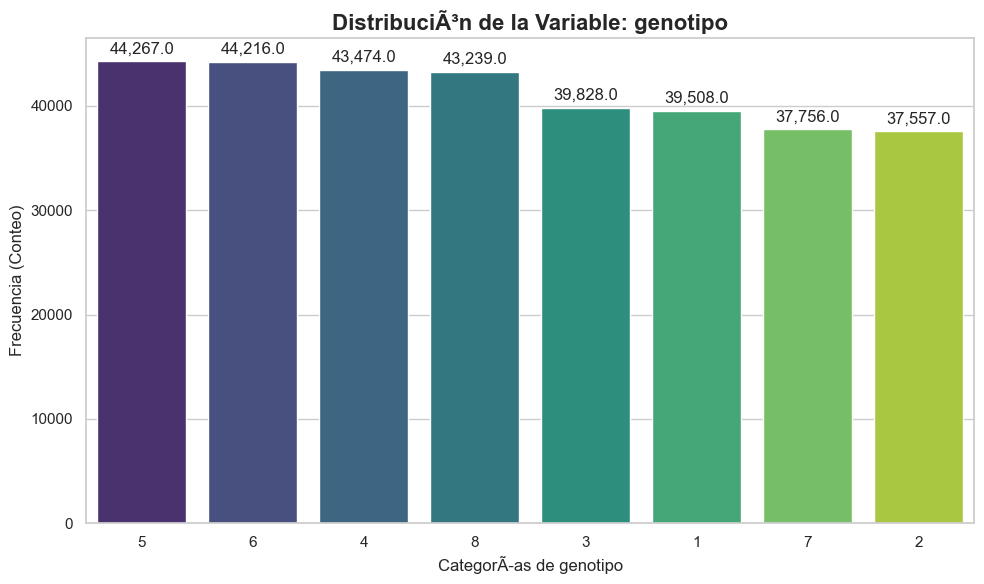

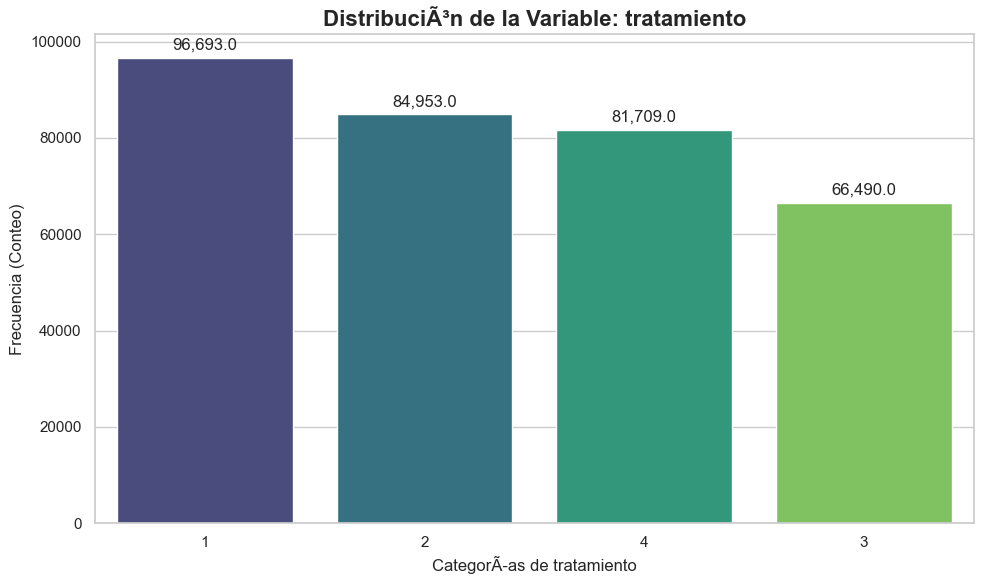

In [ ]:
for col in columnas_categoricas:
    plt.figure(figsize=(10, 6))
    
    # countplot de seaborn que cuenta automáticamente las frecuencias
    ax = sns.countplot(x=col, data=data, order=data[col].value_counts().index, palette='viridis')
    
    # Aí±adir tí­tulo y etiquetas claras
    ax.set_title(f'Distribución de la Variable: {col}', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'Categorí­as de {col}', fontsize=12)
    ax.set_ylabel('Frecuencia (Conteo)', fontsize=12)
    
    # Aí±adir anotaciones sobre cada barra para mayor claridad
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
        
    plt.tight_layout()
    plt.show()

**Interpretación:**

Distribución de frecuencias de las tres variables categóricas:

1. **Genotipo**: Presenta una distribución uniforme entre los 8 genotipos (1-8), con aproximadamente 400,000 muestras cada uno. Esta uniformidad indica un diseí±o experimental balanceado que garantiza representatividad de la diversidad genética.

2. **Banda**: Muestra 10 bandas espectrales diferentes con frecuencias similares (~331,000 muestras cada una), lo que refleja el mismo número de pí­xeles capturados por cada filtro espectral del sensor multiespectral.

3. **Tratamiento**: Aunque relativamente balanceado, existe una ligera variación entre tratamientos. El T1 (deficiencia severa) tiene la mayor representación con ~970,720 muestras, mientras que T3 (deficiencia leve) tiene la menor con ~669,480 muestras. Esta diferencia del 18.3% es manejable pero puede considerarse la aplicación de técnicas de balanceo.

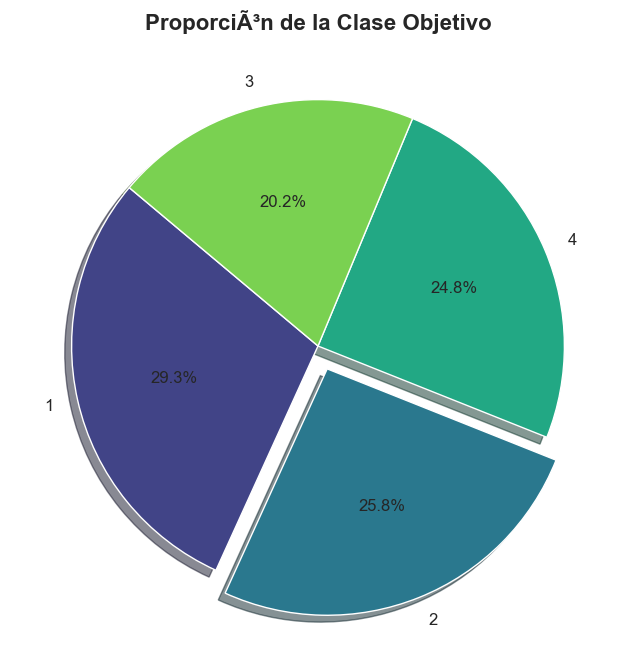

In [ ]:
# Contar las frecuencias
counts = data['tratamiento'].value_counts()

colors = sns.color_palette('viridis', len(counts))
explode = [0.1 if i == counts.idxmax() else 0 for i, _ in enumerate(counts)]

plt.figure(figsize=(8, 8))
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%', # Formato de porcentaje
        startangle=140, 
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12})

plt.title('Proporción de la Clase Objetivo', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()

**Interpretación del gráfico de torta:**

Proporción de cada tratamiento en el dataset:

- **T1 (29.3%)**: Plantas con 25% de fósforo (deficiencia severa) - Mayor representación
- **T2 (25.8%)**: Plantas con 50% de fósforo (deficiencia moderada)
- **T4 (24.8%)**: Plantas con 100% de fósforo (control saludable)
- **T3 (20.2%)**: Plantas con 75% de fósforo (deficiencia leve) - Menor representación

El desbalance es moderado (diferencia de 9.3 puntos porcentuales entre extremos), lo que no deberí­a afectar significativamente el rendimiento del modelo. Sin embargo, es importante monitorear que el modelo no desarrolle un sesgo hacia la clasificación de T1.

**Distribución por Genotipo**

Distribución prácticamente uniforme entre genotipos, con diferencias promedio de ~50K registros entre el mayor y menor representado.

Esta uniformidad es metodológicamente favorable porque:

- Garantiza representatividad de la diversidad genética
- Evita sesgos hacia genotipos especí­ficos
- Permite generalización robusta del modelo
- Con >400K muestras por genotipo, las diferencias no son estadí­sticamente significativas


**Distribución por Tratamiento (Variable Objetivo)**

- **Desbalance moderado:** Diferencia de 9.3 puntos porcentuales entre extremos. Mayor representación de plantas con deficiencia severa (T1) vs deficiencias leves (T3). Puede existir un riesgo de sesgo hacia clasificación de plantas con deficiencia severa.

Se pueden considerar técnicas de balanceo.

### 3.1.2 Variables numéricas

**Distribución de las variables y valores atí­picos**

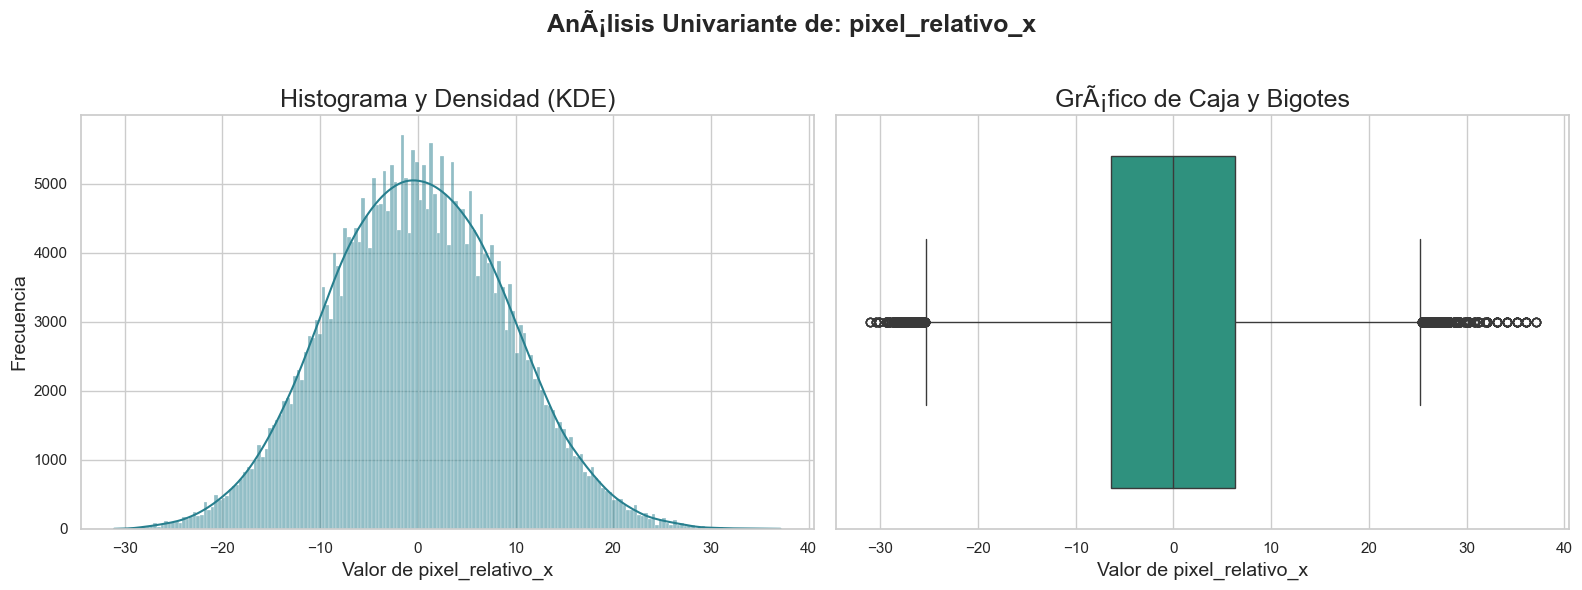

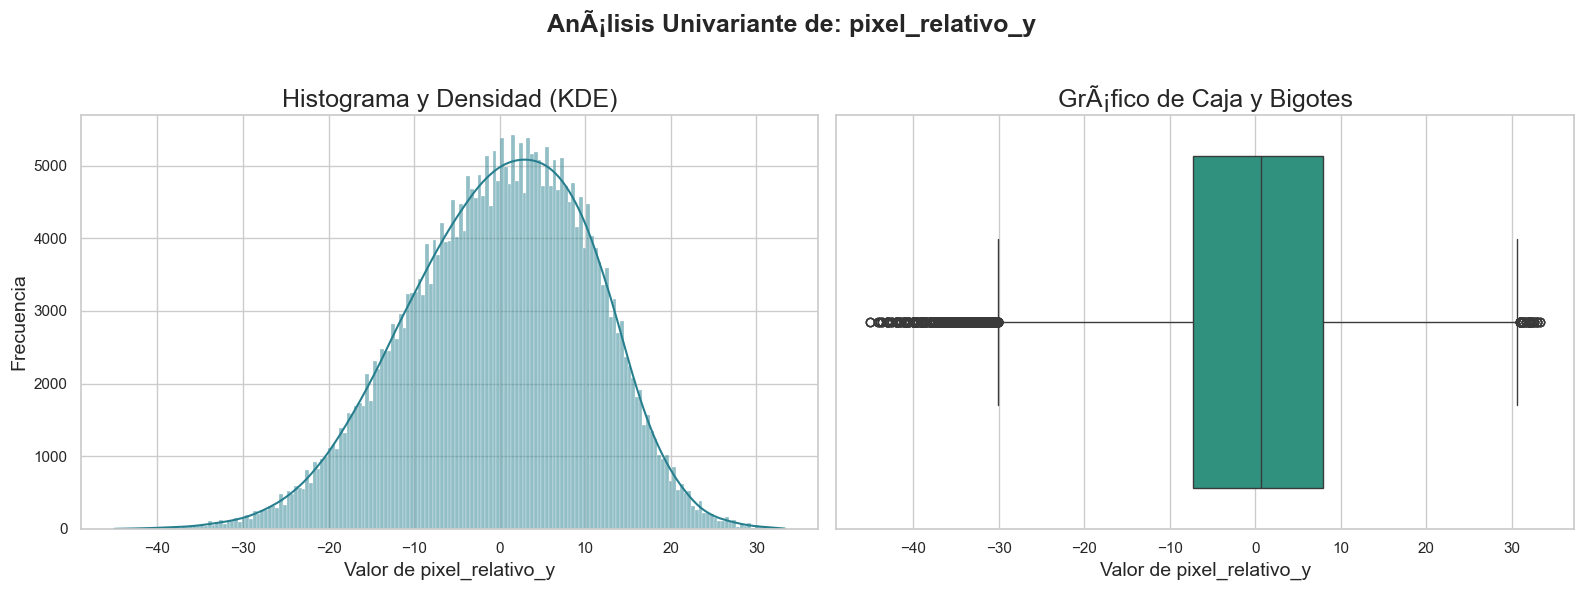

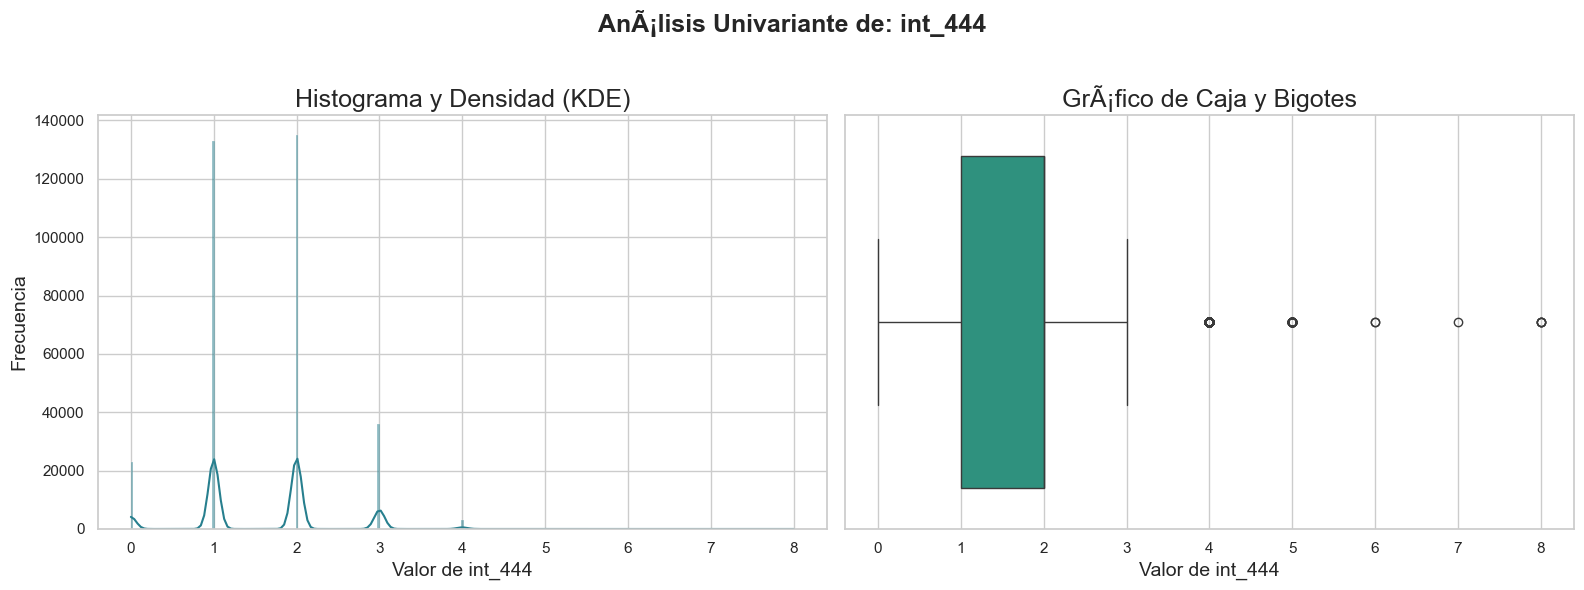

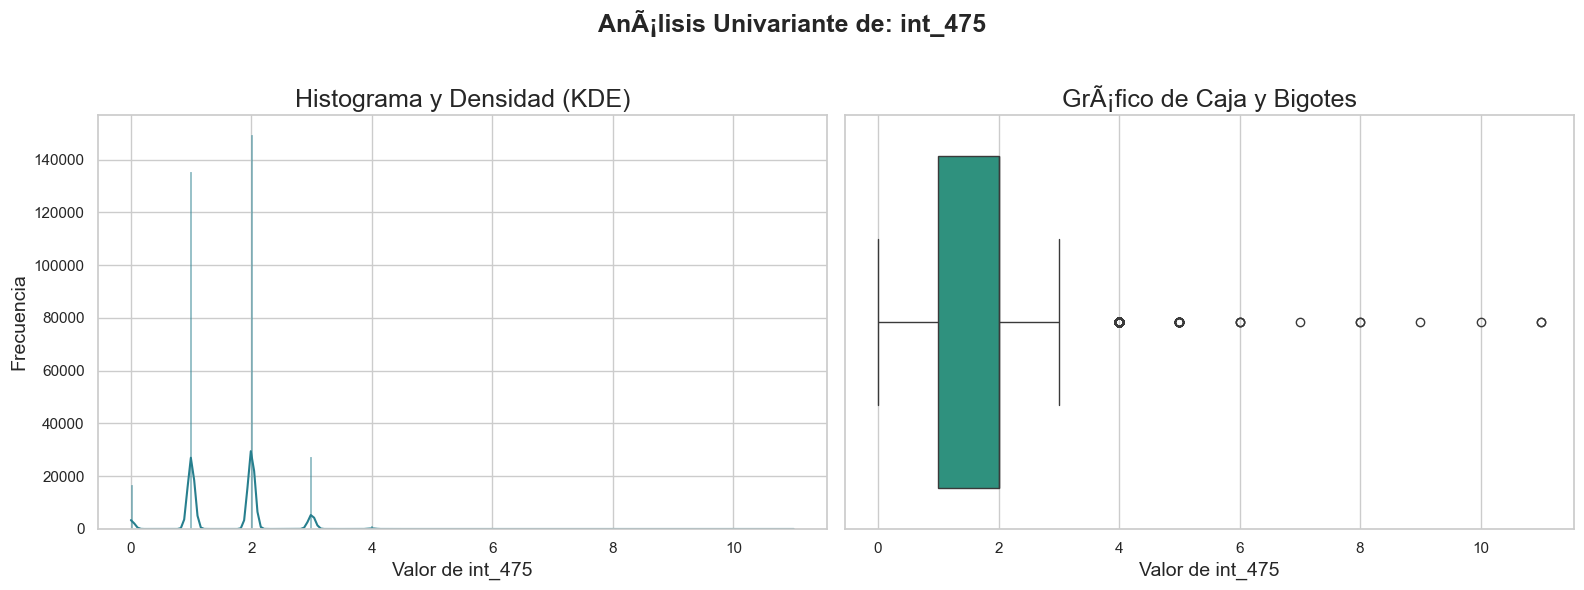

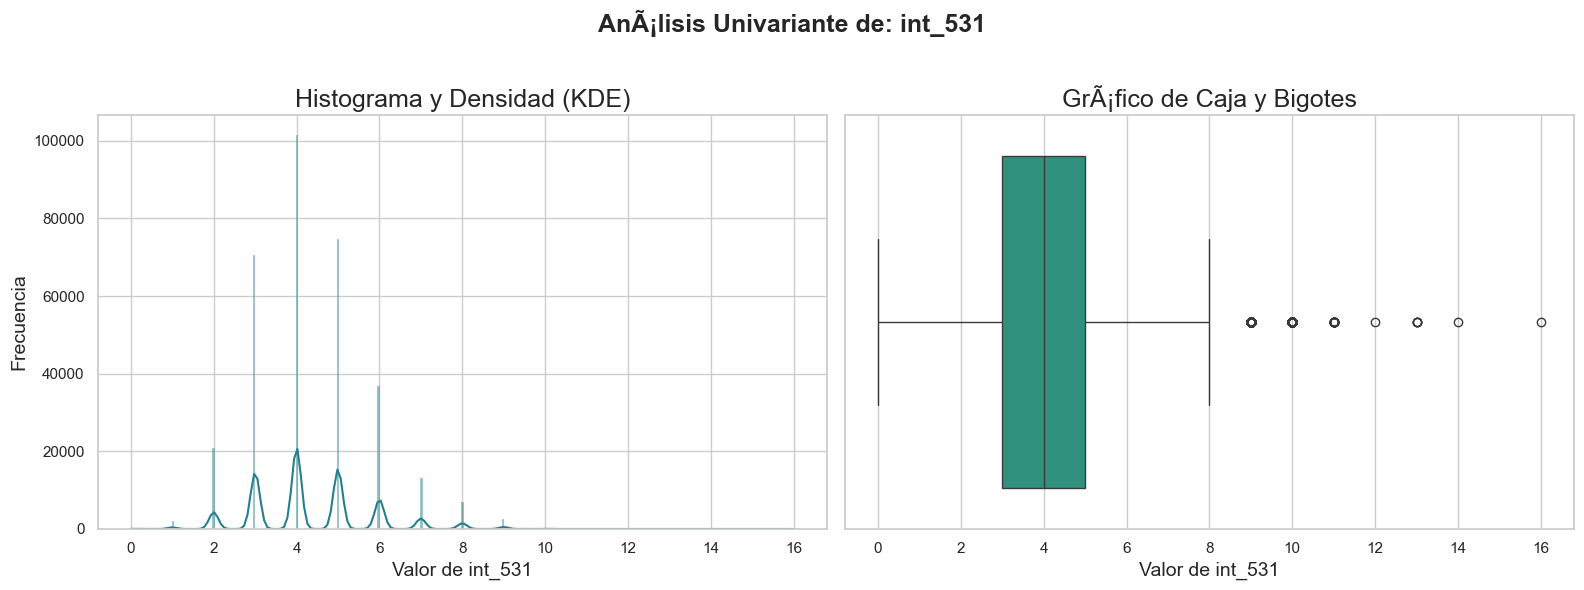

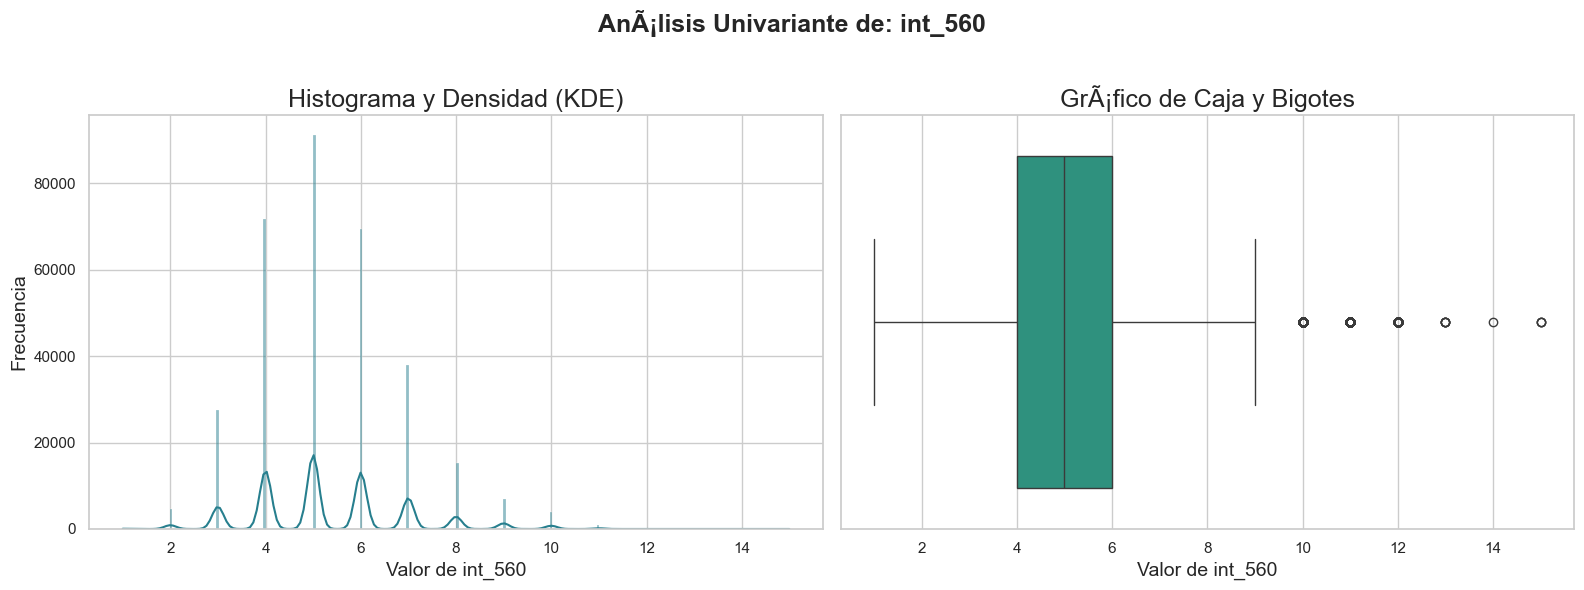

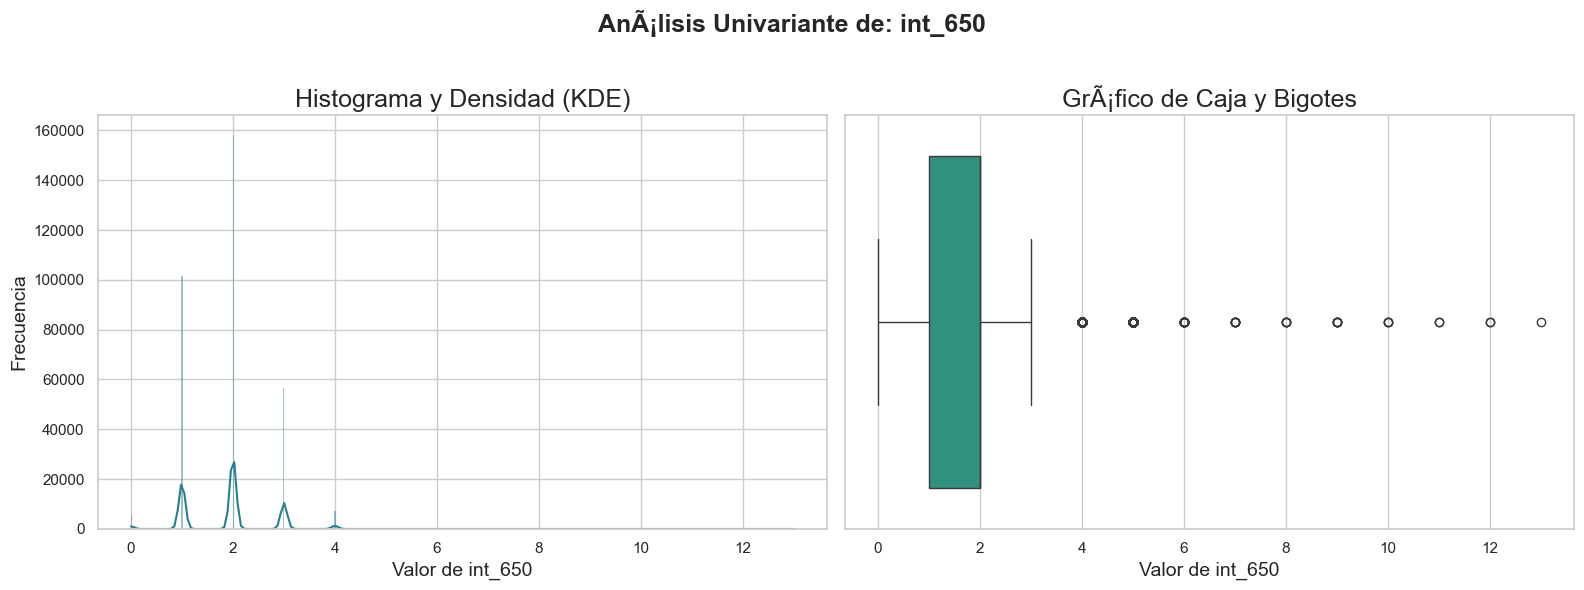

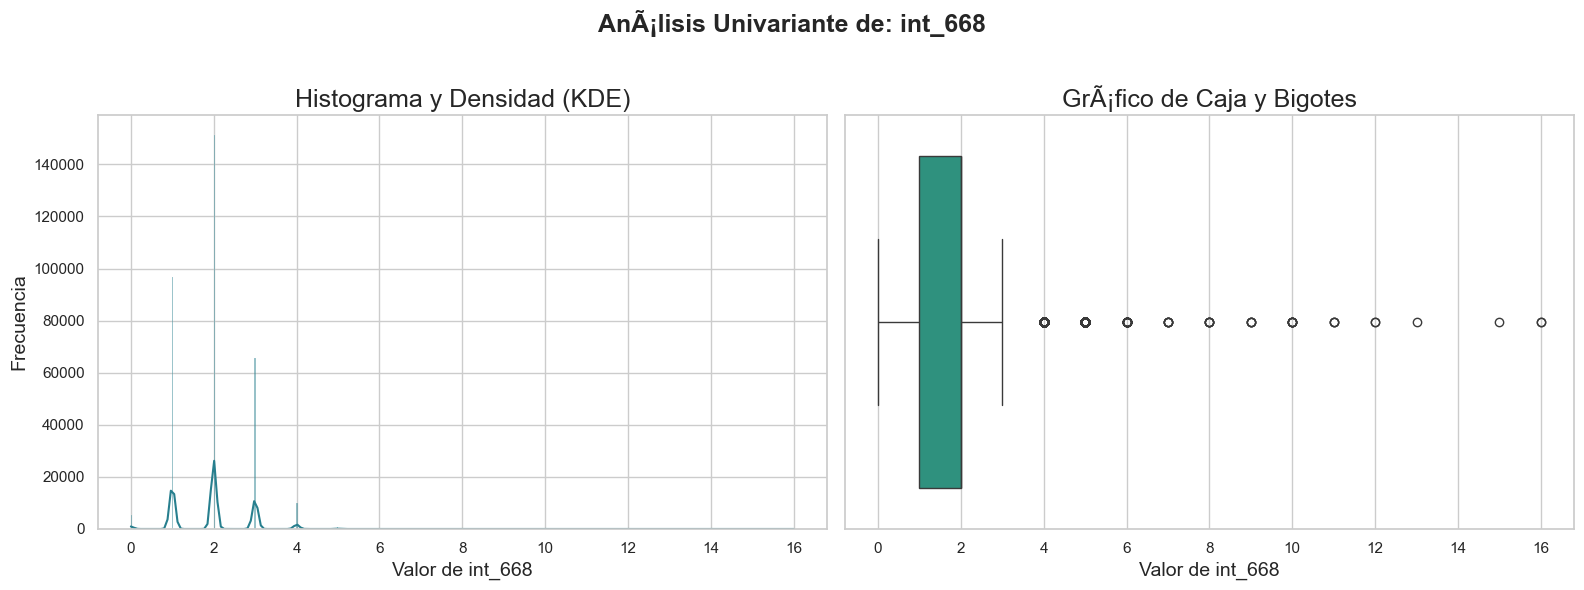

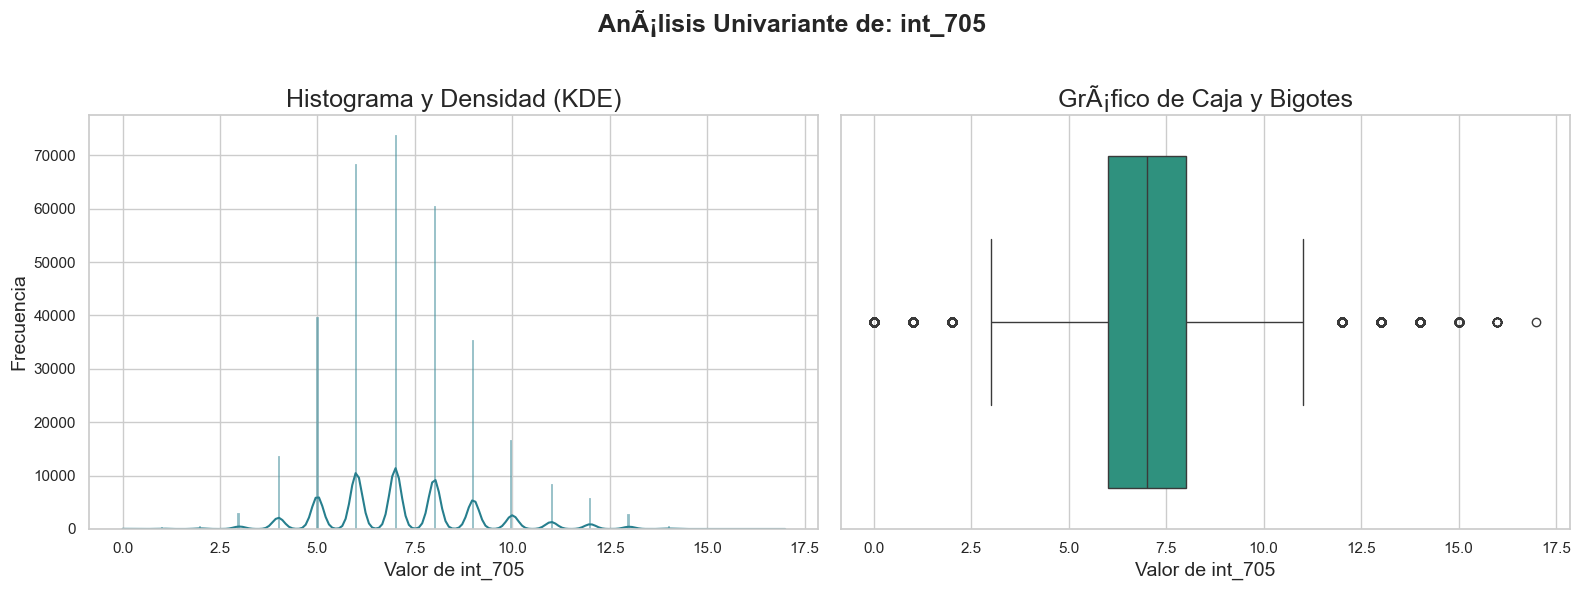

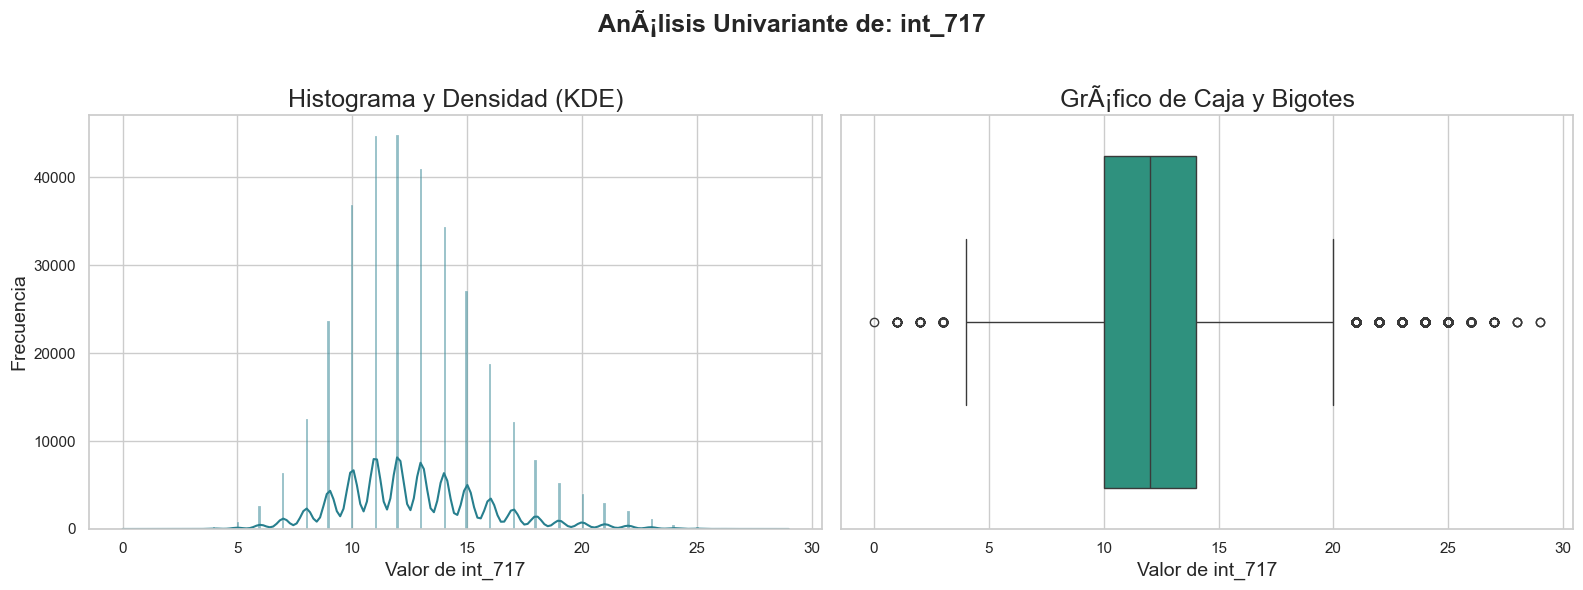

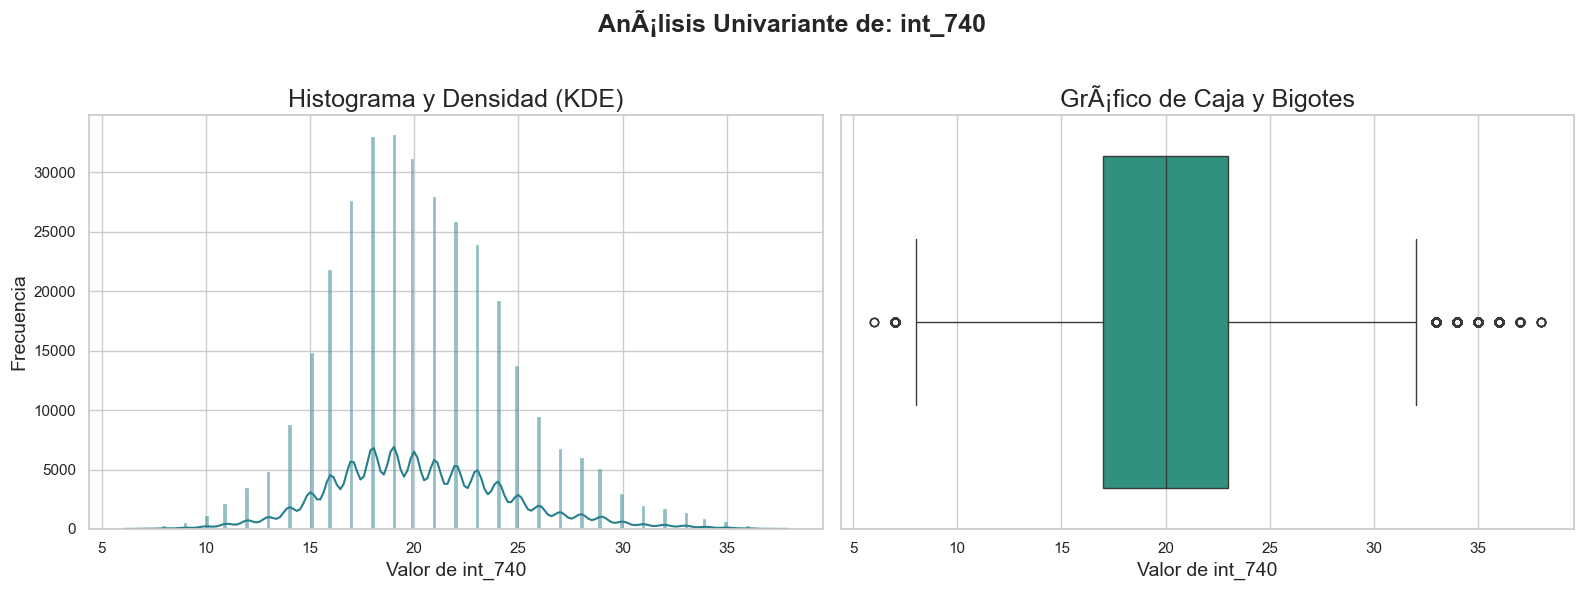

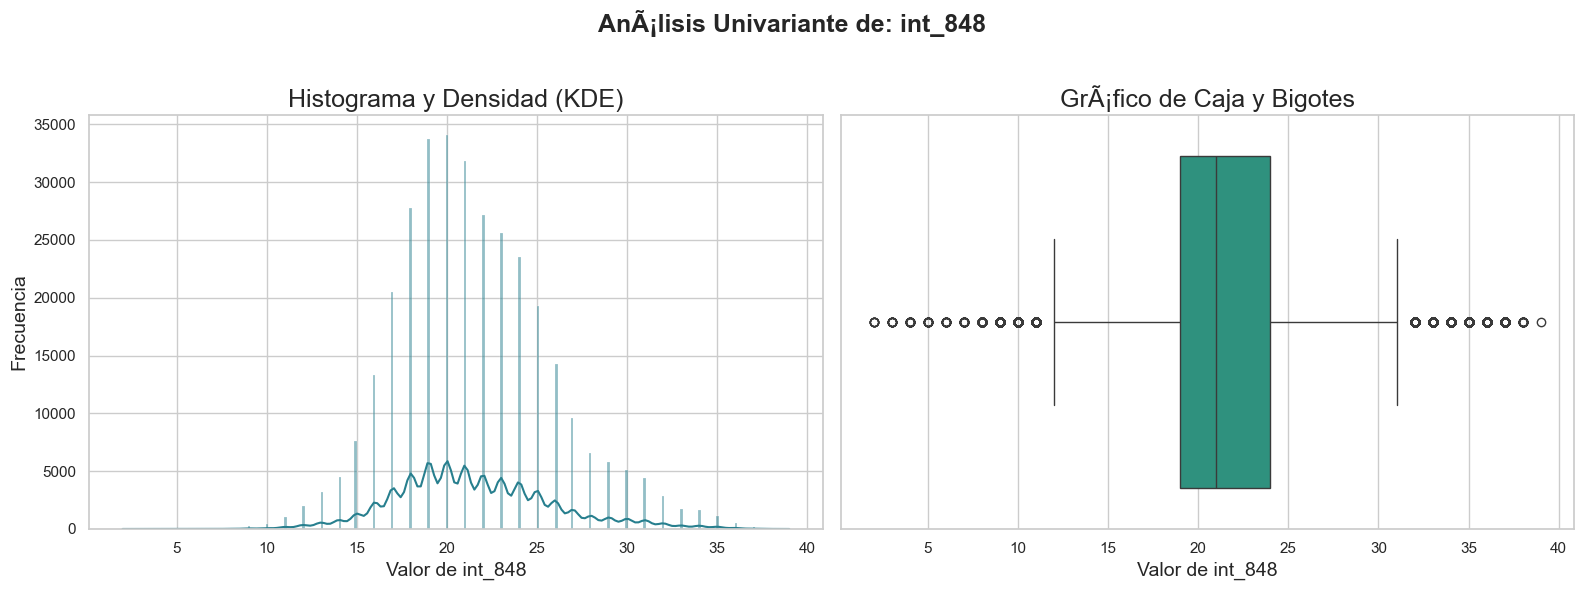

In [ ]:
for col in columnas_numericas:
    # Crear una figura con dos subplots (uno al lado del otro)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Tí­tulo general para la figura
    fig.suptitle(f'Análisis Univariante de: {col}', fontsize=18, fontweight='bold')
    
    # Histograma con KDE (Kernel Density Estimate)
    sns.histplot(data[col], kde=True, ax=axes[0], color=sns.color_palette('viridis')[2])
    axes[0].set_title('Histograma y Densidad (KDE)')
    axes[0].set_xlabel(f'Valor de {col}')
    axes[0].set_ylabel('Frecuencia')
    
    # Gráfico de Caja y Bigotes (Box Plot)
    sns.boxplot(x=data[col], ax=axes[1], color=sns.color_palette('viridis')[3])
    axes[1].set_title('Gráfico de Caja y Bigotes')
    axes[1].set_xlabel(f'Valor de {col}')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar para que el suptitle no se superponga
    plt.show()


## 3.2 Análisis de variables múltiples

### 3.2.1 Numérica vs. Numérica

#### Gráfico de dispersión

In [21]:
# Pairplot sobre un subconjunto de bandas para facilitar visualizacion
pair_band_cols = band_cols[:3] if len(band_cols) >= 3 else band_cols
pair_cols = ["pixel_relativo_x", "pixel_relativo_y"] + pair_band_cols + ["tratamiento"]

sample_data = data[pair_cols].sample(n=min(3000, len(data)), random_state=42)

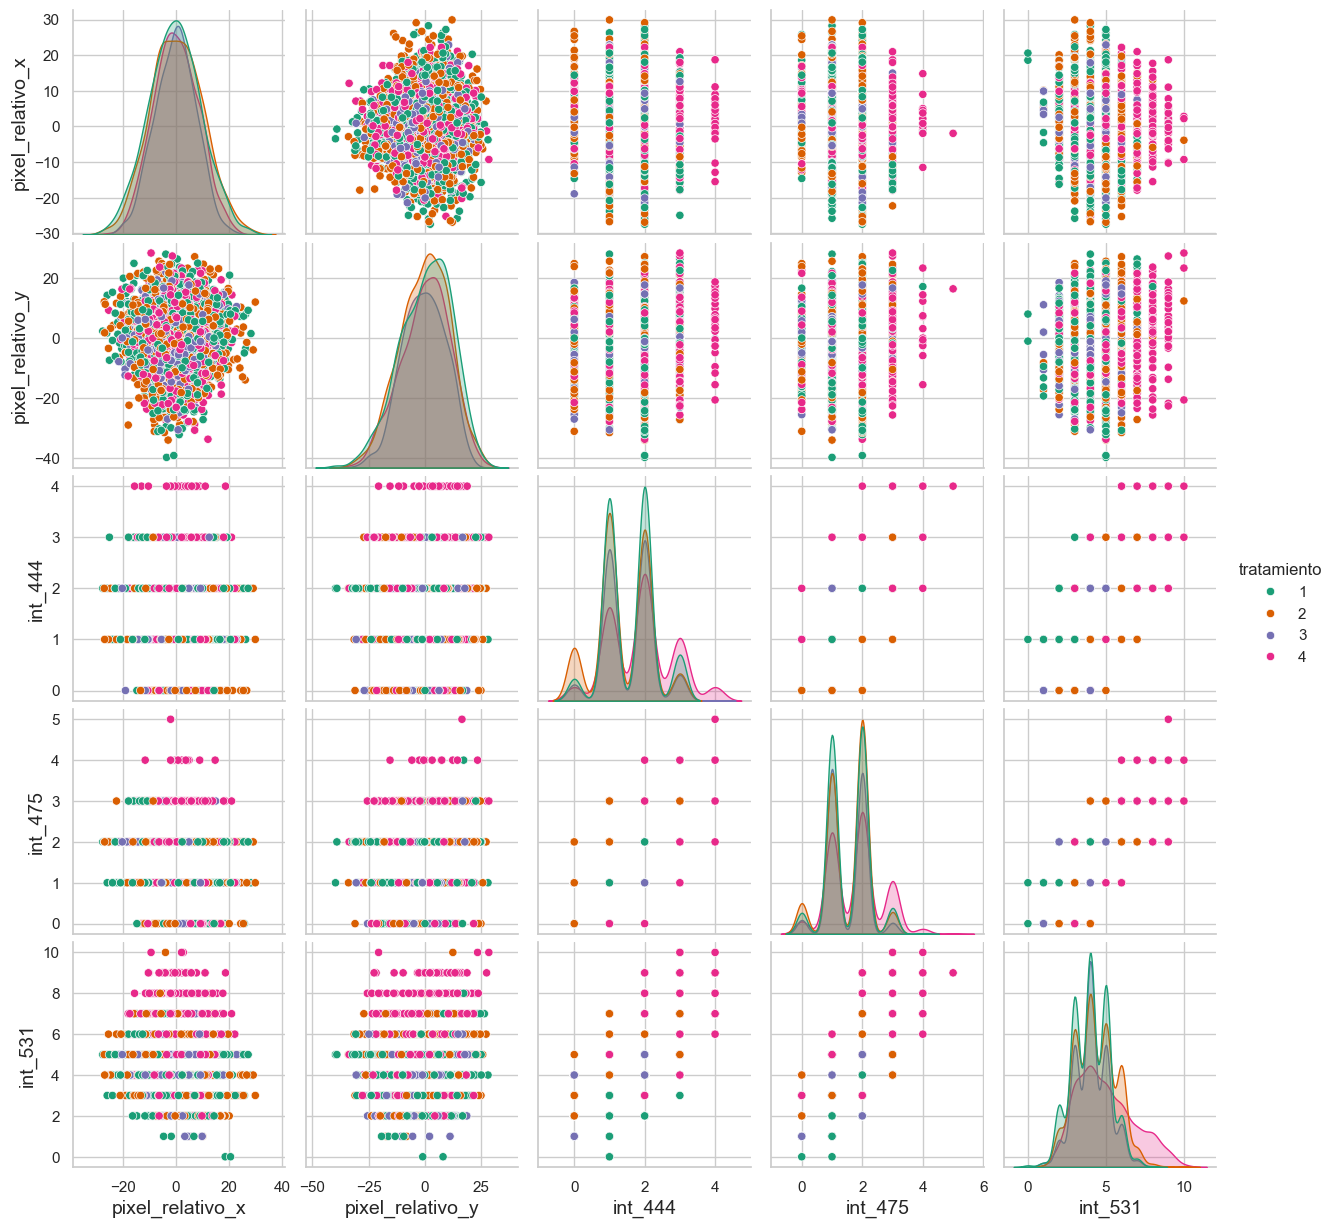

In [22]:
sns.pairplot(sample_data, hue="tratamiento", palette="Dark2")

Text(0.5, 0.98, 'Relacion entre pixel relativo y e intensidad por banda')

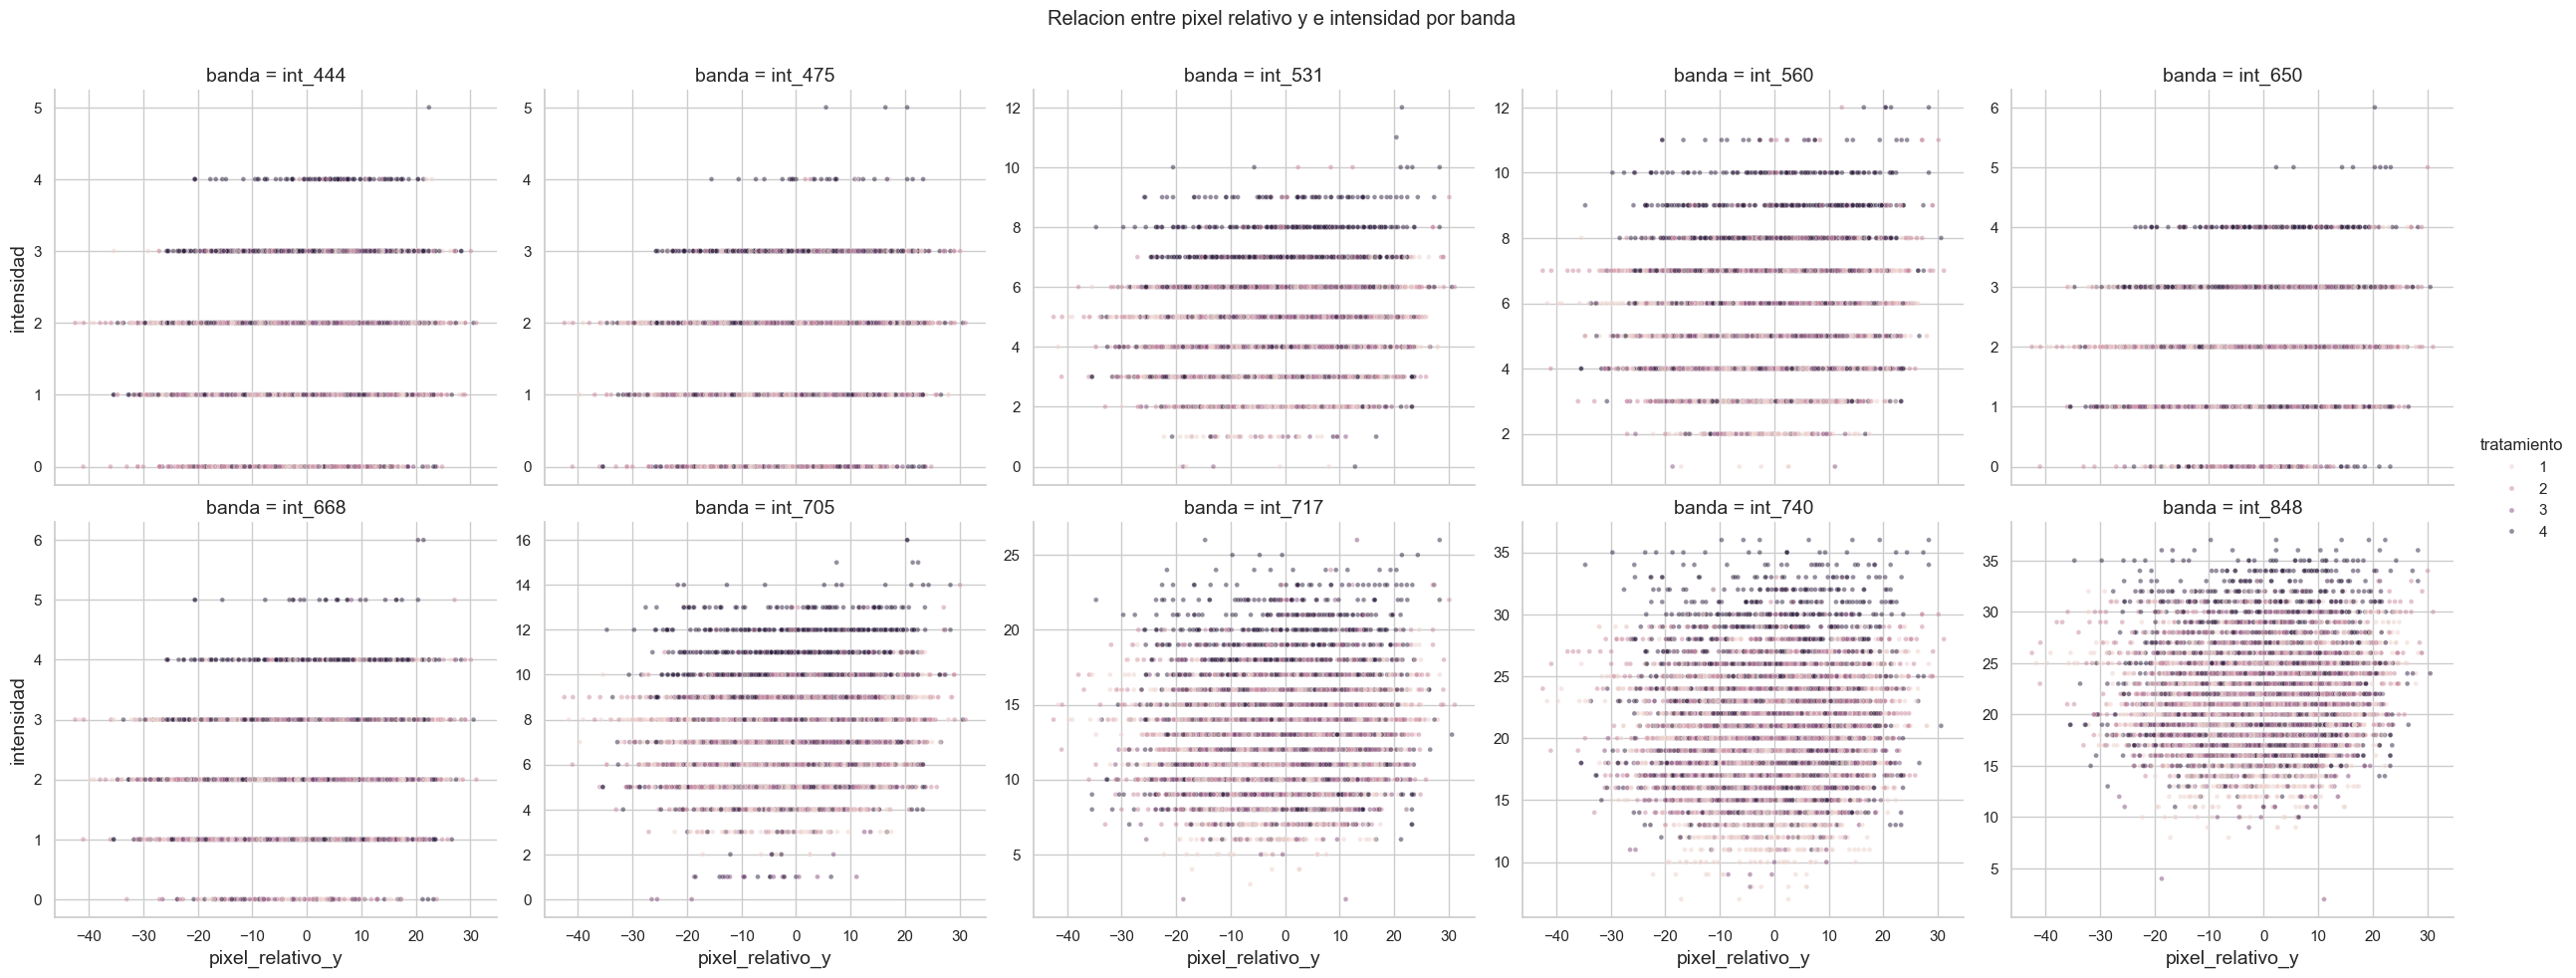

In [23]:
# Scatter por banda en formato largo (muestra)
scatter_long = sample_long_by_band(data, band_cols, n=10000, seed=42)

g = sns.relplot(
    data=scatter_long,
    x="pixel_relativo_y",
    y="intensidad",
    hue="tratamiento",
    col="banda",
    col_wrap=5,
    kind="scatter",
    alpha=0.5,
    s=12,
    facet_kws={"sharex": True, "sharey": False},
)

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Relacion entre pixel relativo y e intensidad por banda")

#### Matriz de correlaciones

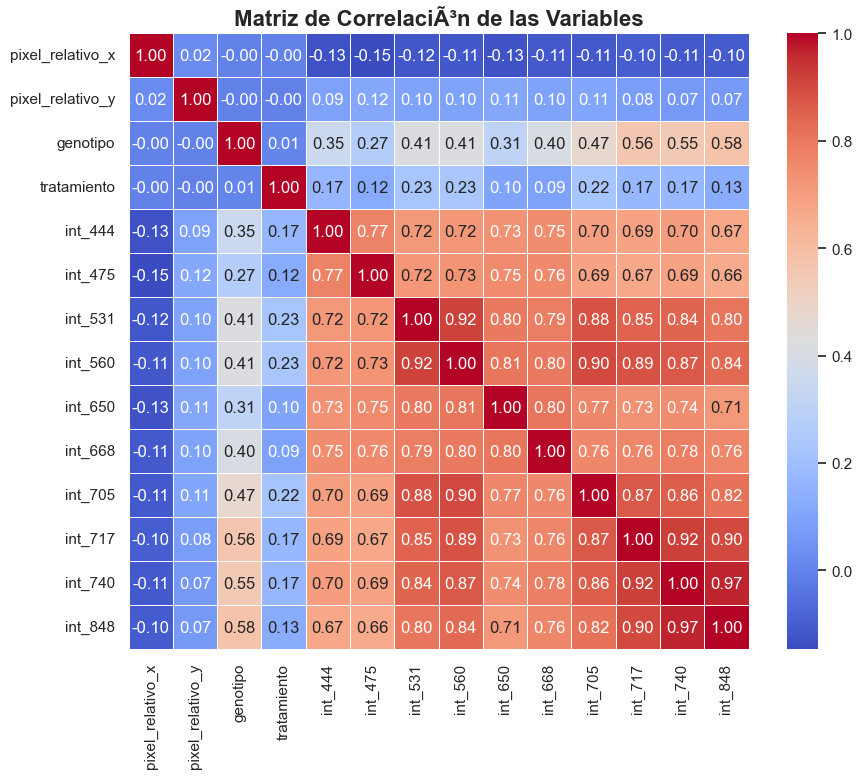

In [ ]:
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

# Usamos un mapa de calor para visualizar la matriz
sns.heatmap(
    corr_matrix, 
    annot=True,       # Muestra los valores de correlación en las celdas
    cmap='coolwarm',  # Paleta de colores ideal para correlaciones (-1: azul, 0: blanco, 1: rojo)
    fmt=".2f",        # Formato de los números a dos decimales
    linewidths=.5
)

plt.title('Matriz de Correlación de las Variables', fontsize=16, fontweight='bold')
plt.show()

### 3.2.2 Numérica vs. Categórica

Text(0.5, 0.98, 'Distribucion de intensidad por tratamiento en cada banda')

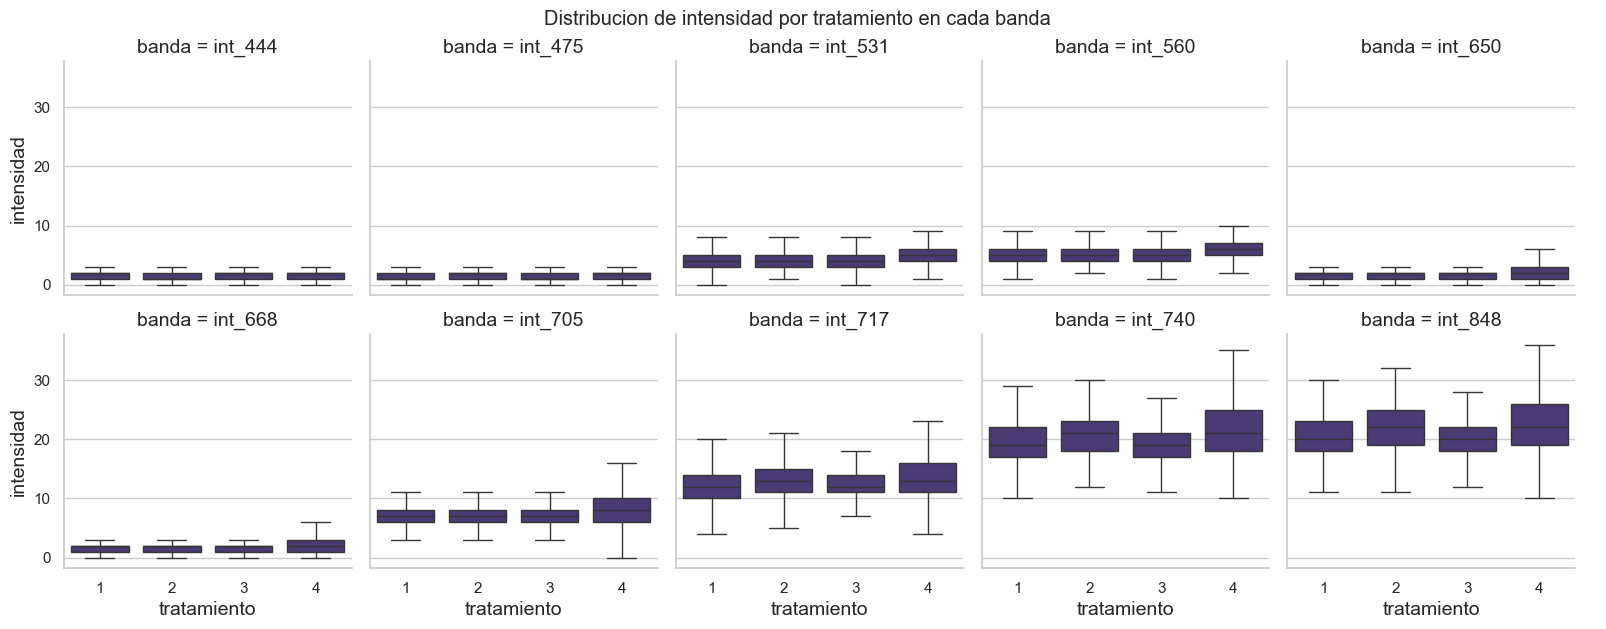

In [25]:
# Boxplot por tratamiento para cada banda (formato largo)
box_long = sample_long_by_band(data, band_cols, n=20000, seed=43)

g = sns.catplot(
    data=box_long,
    x="tratamiento",
    y="intensidad",
    col="banda",
    col_wrap=5,
    kind="box",
    showfliers=False,
    height=3.2,
    aspect=1.0,
)

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Distribucion de intensidad por tratamiento en cada banda")

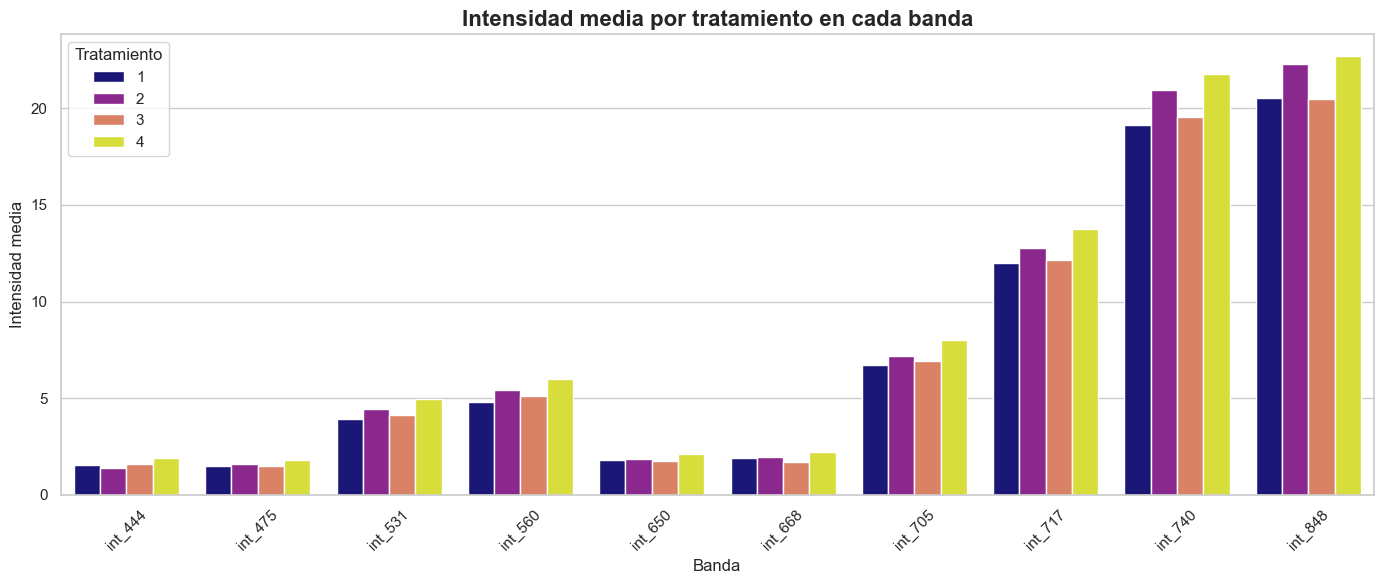

In [26]:
# Intensidad media por tratamiento y por banda (agregado)
bar_long = sample_long_by_band(data, band_cols, n=20000, seed=44)
mean_by_band_treatment = (
    bar_long.groupby(["banda", "tratamiento"], as_index=False)["intensidad"]
    .mean()
)

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=mean_by_band_treatment,
    x="banda",
    y="intensidad",
    hue="tratamiento",
    palette="plasma",
)
ax.set_title("Intensidad media por tratamiento en cada banda", fontsize=16, fontweight="bold")
ax.set_xlabel("Banda", fontsize=12)
ax.set_ylabel("Intensidad media", fontsize=12)
plt.legend(title="Tratamiento")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2.3 Categórica vs. Categórica

In [27]:
contingency_table = pd.crosstab(data['genotipo'], data['tratamiento'])

print("Tabla de Contingencia (Frecuencias Absolutas):")
print(contingency_table)

contingency_table_percent = pd.crosstab(data['genotipo'], data['tratamiento'], normalize='index') * 100

print("\nTabla de Contingencia (Porcentajes por Fila - Genotipo):")
print(contingency_table_percent.round(2))

Tabla de Contingencia (Frecuencias Absolutas):
tratamiento      1      2     3      4
genotipo                              
1            11505  10909  6896  10198
2            10184   9136  9063   9174
3            12082  10331  8223   9192
4            11780  12859  9697   9138
5            13206  12537  8550   9974
6            13045  11396  8079  11696
7            12114   6936  8436  10270
8            12777  10849  7546  12067

Tabla de Contingencia (Porcentajes por Fila - Genotipo):
tratamiento      1      2      3      4
genotipo                               
1            29.12  27.61  17.45  25.81
2            27.12  24.33  24.13  24.43
3            30.34  25.94  20.65  23.08
4            27.10  29.58  22.31  21.02
5            29.83  28.32  19.31  22.53
6            29.50  25.77  18.27  26.45
7            32.08  18.37  22.34  27.20
8            29.55  25.09  17.45  27.91


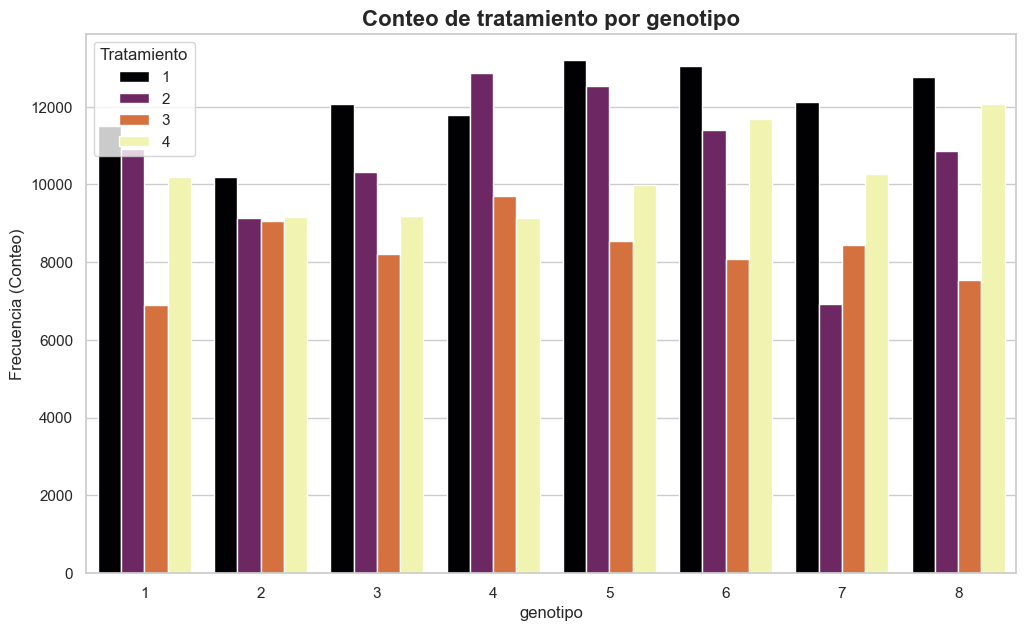

In [28]:
plt.figure(figsize=(12, 7))
sns.countplot(data=data, x='genotipo', hue='tratamiento', palette='inferno')
plt.title('Conteo de tratamiento por genotipo', fontsize=16, fontweight='bold')
plt.xlabel('genotipo', fontsize=12)
plt.ylabel('Frecuencia (Conteo)', fontsize=12)
plt.legend(title='Tratamiento')
plt.show()

#### Gráfico de Barras apiladas al 100%

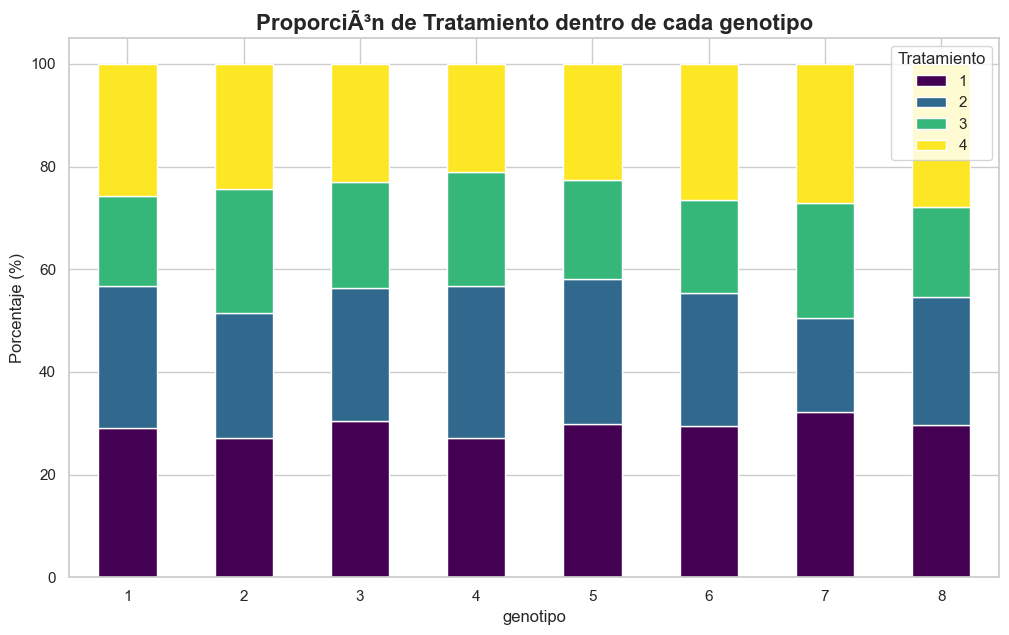

In [ ]:
contingency_table_percent.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7),
    colormap='viridis'
)
plt.title('Proporción de Tratamiento dentro de cada genotipo', fontsize=16, fontweight='bold')
plt.xlabel('genotipo', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='Tratamiento')
plt.xticks(rotation=0)
plt.show()

## 3.3 Identificación sisemática de outliers

In [30]:
def identificar_outliers_iqr(dataframe, columna):
    """Identifica outliers en una columna usando el metodo del IQR."""
    q1 = dataframe[columna].quantile(0.25)
    q3 = dataframe[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    return {
        "columna": columna,
        "metodo": "IQR",
        "limite_inferior": float(limite_inferior),
        "limite_superior": float(limite_superior),
        "n_outliers": int(len(outliers)),
    }


def identificar_outliers_std(dataframe, columna, z_score_threshold=3):
    """Identifica outliers usando desviaciones estandar de la media."""
    media = dataframe[columna].mean()
    std = dataframe[columna].std()

    limite_superior = media + z_score_threshold * std
    limite_inferior = media - z_score_threshold * std

    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    return {
        "columna": columna,
        "metodo": f"Z>{z_score_threshold}",
        "limite_inferior": float(limite_inferior),
        "limite_superior": float(limite_superior),
        "n_outliers": int(len(outliers)),
    }


# Outliers por banda espectral
res_iqr = [identificar_outliers_iqr(data, b) for b in band_cols]
res_std = [identificar_outliers_std(data, b, z_score_threshold=3) for b in band_cols]

outliers_resumen = pd.DataFrame(res_iqr + res_std)
outliers_resumen = outliers_resumen.sort_values(["metodo", "columna"]).reset_index(drop=True)

print("Resumen de outliers por banda:")
display(outliers_resumen)

Resumen de outliers por banda:


,columna,metodo,limite_inferior,limite_superior,n_outliers
0,int_444,IQR,-0.500000,3.500000,3081
1,int_475,IQR,-0.500000,3.500000,1067
2,int_531,IQR,0.000000,8.000000,2786
3,int_560,IQR,1.000000,9.000000,4966
4,int_650,IQR,-0.500000,3.500000,7418
5,int_668,IQR,-0.500000,3.500000,10551
6,int_705,IQR,3.000000,11.000000,10314
7,int_717,IQR,4.000000,20.000000,6902
8,int_740,IQR,8.000000,32.000000,3238
9,int_848,IQR,11.500000,31.500000,9936


Valores de intensidad > 27-30:

- Posibles causas biológicas:

    - Nervaduras principales con mayor reflectancia
    - Bordes foliares con diferente estructura anatómica
    - Estructuras superficiales especializadas
    - Regiones senescentes con menor contenido de clorofila

No eliminar outliers - pueden contener información biológica relevante

# 4. Preprocesamiento de Datos

## 4.1. División de datos en conjuntos de entrenamiento y prueba

In [31]:
# Se usan splits por objeto predefinidos (70/30) desde CSV
y_train = data_train['tratamiento'].copy()
y_test = data_test['tratamiento'].copy()

In [32]:
# Definir features del esquema v4 (formato ancho)
feature_cols = ["pixel_relativo_x", "pixel_relativo_y", "genotipo"] + band_cols

missing_train = [c for c in feature_cols if c not in data_train.columns]
missing_test = [c for c in feature_cols if c not in data_test.columns]
if missing_train or missing_test:
    raise ValueError(f"Faltan columnas en train/test. train={missing_train}, test={missing_test}")

X_train = data_train[feature_cols].copy()
X_test = data_test[feature_cols].copy()

excluded_cols = [c for c in data_train.columns if c not in feature_cols + ["tratamiento"]]
print(f"Columnas usadas ({len(feature_cols)}): {feature_cols}")
if excluded_cols:
    print(f"Columnas excluidas: {excluded_cols}")

Columnas usadas (13): ['pixel_relativo_x', 'pixel_relativo_y', 'genotipo', 'int_444', 'int_475', 'int_531', 'int_560', 'int_650', 'int_668', 'int_705', 'int_717', 'int_740', 'int_848']
Columnas excluidas: ['object_id', 'split']


## 4.2. Normalización de caracterí­sticas

La normalización mediante MinMaxScaler transforma las caracterí­sticas al rango [0, 1], preservando las relaciones entre valores.

In [ ]:
# Inicialización y aplicación del escalador MinMaxScaler
scaler = MinMaxScaler() 

# Ajuste del escalador con datos de entrenamiento y transformación
X_train_scaled = scaler.fit_transform(X_train) 

# Transformación del conjunto de prueba usando los mismos parámetros
X_test_scaled = scaler.transform(X_test)

## 4.3. Codificación de tratamiento

Algoritmos de aprendizaje automático (como XGBoost) requieren que las etiquetas de clase sean enteros consecutivos comenzando desde 0. LabelEncoder realiza esta transformación automáticamente.

**XGBoost**

In [ ]:
# Inicialización y aplicación del codificador de etiquetas
le = LabelEncoder()

# Codificación de las etiquetas de entrenamiento: [1, 2, 3, 4] â†’ [0, 1, 2, 3]
y_train_encoded = le.fit_transform(y_train)

# Codificación de las etiquetas de prueba usando el mismo mapeo
y_test_encoded = le.transform(y_test)

## 4.5. Persistencia de datos procesados

In [ ]:
# Almacenamiento de todos los conjuntos de datos procesados en formato comprimido .npz
np.savez(
    "results/data/train_data_frijol.npz",
    X_train_scaled=X_train_scaled,
    X_test_scaled=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    y_train_encoded=y_train_encoded,
    y_test_encoded=y_test_encoded,
)

## 4.6. Carga de datos preprocesados

In [ ]:
# Carga del archivo .npz con todos los conjuntos de datos procesados
train_data = np.load("results/data/train_data_frijol.npz")

X_train_scaled = train_data["X_train_scaled"]
X_test_scaled = train_data["X_test_scaled"]
y_train = train_data["y_train"]
y_test = train_data["y_test"]
y_train_encoded = train_data["y_train_encoded"]
y_test_encoded = train_data["y_test_encoded"]

# 5. Entrenamiento de Modelos de Aprendizaje Automático

Esta sección implementa y entrena múltiples algoritmos de clasificación para comparar su rendimiento en la tarea de detección de deficiencia de fósforo. Los modelos seleccionados representan diferentes paradigmas de aprendizaje:

**Modelos implementados:**
1. **K-Nearest Neighbors (KNN)**: Clasificador basado en instancias que utiliza proximidad espacial
2. **Random Forest (RF)**: Ensemble de árboles de decisión con votación mayoritaria
3. **XGBoost**: Gradient boosting optimizado con regularización avanzada
4. **Multi-Layer Perceptron (MLP)**: Red neuronal artificial con capas ocultas

**Objetivos:**
- Identificar el algoritmo más adecuado para este problema especí­fico
- Comparar arquitecturas de aprendizaje (basado en instancias, árboles, boosting, redes neuronales)
- Establecer lí­nea base de rendimiento para futuras optimizaciones
- Registrar tiempos de entrenamiento para considerar eficiencia computacional

In [ ]:
# Definición de funciones auxiliares para medir tiempos de entrenamiento

def medir_tiempo_entrenamiento(func):
    """
    Decorador para medir y registrar el tiempo de entrenamiento de modelos.
    Args:
        func: Función de entrenamiento a decorar
    Returns:
        wrapper: Función decorada que incluye medición de tiempo
    """
    def wrapper(*args, nombre_modelo=None, **kwargs):
        # Identificación del modelo a entrenar
        modelo = None
        if args:
            modelo = args[0]
        elif "estimator" in kwargs:
            modelo = kwargs["estimator"]

        # Etiqueta descriptiva para el registro de tiempo
        etiqueta = nombre_modelo or (modelo.__class__.__name__ if modelo is not None else func.__name__)
        
        # Medición del tiempo de entrenamiento
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        
        # Registro del tiempo transcurrido
        print(f"â±ï¸ {etiqueta} entrenado en {fin - inicio:.2f}s")
        return resultado

    return wrapper


@medir_tiempo_entrenamiento
def train_model(estimator):
    """
    Función genérica de entrenamiento para cualquier estimador de scikit-learn.
    
    Args:
        estimator: Objeto de modelo de scikit-learn no entrenado
    
    Returns:
        estimator: Modelo entrenado con datos de entrenamiento escalados
    """
    estimator.fit(X_train_scaled, y_train)
    return estimator

## 5.1. K-Nearest Neighbors (KNN)

- **Simplicidad**: No requiere fase explí­cita de entrenamiento (lazy learning)
- **No linealidad**: Puede capturar fronteras de decisión complejas
- **Sensibilidad a escala**: Requiere normalización de caracterí­sticas (ya aplicada)
- **Computacionalmente intensivo**: El costo de predicción crece con el tamaí±o del dataset

In [ ]:
# Inicialización del clasificador KNN con parámetros por defecto
knn = KNeighborsClassifier(n_jobs=-1)

In [ ]:
# Entrenamiento del modelo KNN con medición de tiempo
knn_classifier = train_model(knn)

â±ï¸ KNeighborsClassifier entrenado en 0.70s


In [ ]:
# Persistencia del modelo entrenado en disco
joblib.dump(knn_classifier, "models/frijol/modelo_knn.pkl")

['models/frijol/modelo_knn_v4.pkl']

## 5.2. Random Forest (RF)

- **Manejo de no linealidades**: Captura interacciones complejas sin preprocesamiento

In [ ]:
# Inicialización del clasificador Random Forest
rfc = RandomForestClassifier(n_jobs=-1, random_state=12)

In [ ]:
# Entrenamiento del clasificador Random Forest con medición de tiempo
rf_classifier = train_model(rfc)

â±ï¸ RandomForestClassifier entrenado en 9.79s


In [ ]:
# Persistencia del modelo Random Forest entrenado
joblib.dump(rf_classifier, "models/frijol/modelo_rfc.pkl")

['models/frijol/modelo_rfc_v4.pkl']

## 5.3. XGBoost (Extreme Gradient Boosting)

- **Regularización**: Incorpora L1 (Lasso) y L2 (Ridge) para prevenir sobreajuste
- **Manejo eficiente**: Optimizado para datasets grandes y caracterí­sticas dispersas
- **Paralelización**: Construcción paralela de árboles mediante algoritmos avanzados

In [ ]:
# Inicialización del clasificador XGBoost con parámetros por defecto
xgbc = xgb.XGBClassifier(random_state=42)

In [ ]:
# Entrenamiento del clasificador XGBoost con medición manual de tiempo
# Utiliza etiquetas codificadas (y_train_encoded) con valores [0, 1, 2, 3]
inicio = time.time()
xgb_classifier = xgbc.fit(X_train_scaled, y_train_encoded)
fin = time.time()
print(f"â±ï¸ XGBClassifier entrenado en {fin - inicio:.2f}s")

â±ï¸ XGBClassifier entrenado en 3.32s


In [ ]:
# Persistencia del modelo XGBoost entrenado
joblib.dump(xgb_classifier, "models/frijol/modelo_xgb.pkl")

['models/frijol/modelo_xgb_v4.pkl']

## 5.4. Multi-Layer Perceptron (MLP)

- **Aproximación universal**: Puede aproximar cualquier función continua con suficientes neuronas
- **Aprendizaje de caracterí­sticas**: Descubre automáticamente representaciones óptimas
- **No linealidad**: Captura relaciones complejas entre variables

In [ ]:
# Inicialización del clasificador Multi-Layer Perceptron con configuración por defecto
mlp = MLPClassifier()

In [ ]:
# Entrenamiento del clasificador MLP con medición de tiempo
mlp_classifier = train_model(mlp)

â±ï¸ MLPClassifier entrenado en 420.22s


In [ ]:
# Persistencia del modelo MLP entrenado
joblib.dump(mlp_classifier, "models/frijol/modelo_mlp.pkl")

['models/frijol/modelo_mlp_v4.pkl']

## 5.5. Carga de modelos previamente entrenados

In [ ]:
knn_classifier = joblib.load("models/frijol/modelo_knn.pkl")
rf_classifier = joblib.load("models/frijol/modelo_rfc.pkl")
xgb_classifier = joblib.load("models/frijol/modelo_xgb.pkl")
mlp_classifier = joblib.load("models/frijol/modelo_mlp.pkl")

# 6. Generación de Predicciones

In [ ]:
# Definición de funciones auxiliares para predicción con medición de tiempo

def medir_tiempo_prediccion(func):
    """
    Decorador para medir y registrar el tiempo de predicción de modelos.
    
    Args:
        func: Función de predicción a decorar
    
    Returns:
        wrapper: Función decorada que incluye medición de tiempo
    """
    def wrapper(estimator, type: str):
        etiqueta = estimator.__class__.__name__
        inicio = time.time()
        resultado = func(estimator, type)
        fin = time.time()
        print(f"â±ï¸ {etiqueta} ({type}) predicho en {fin - inicio:.2f}s")
        return resultado
    return wrapper

In [ ]:
@medir_tiempo_prediccion
def make_prediction(estimator, type: str):
    """
    Función genérica para generar predicciones con cualquier modelo entrenado.
    
    Args:
        estimator: Modelo entrenado de scikit-learn
        type: Tipo de conjunto ('train' o 'test')
    
    Returns:
        prediction: Array de predicciones para el conjunto especificado
    
    Raises:
        ValueError: Si el tipo especificado no es 'train' o 'test'
    """
    if type == "test":
        prediction = estimator.predict(X_test_scaled)
    elif type == "train":
        prediction = estimator.predict(X_train_scaled)
    else:
        raise ValueError("type debe ser 'train' o 'test'")
    return prediction

## 6.1. Predicciones con K-Nearest Neighbors (KNN)

In [42]:
knn_prediction_train = make_prediction(knn_classifier, "train")

â±ï¸ KNeighborsClassifier (train) predicho en 16.91s


In [43]:
knn_prediction_test = make_prediction(knn_classifier, "test")

â±ï¸ KNeighborsClassifier (test) predicho en 9.15s


### 6.1.1 Guardar predicciones

In [ ]:
joblib.dump(knn_prediction_test, "results/predictions/frijol/test/predicciones_knn_test.pkl")
joblib.dump(knn_prediction_train, "results/predictions/frijol/train/predicciones_knn_train.pkl")

['results/predictions/frijol/train/predicciones_knn_train_v2.pkl']

### 6.1.2 Cargar predicciones

In [ ]:
knn_prediction_test = joblib.load("results/predictions/frijol/test/predicciones_knn_test.pkl")
knn_prediction_train = joblib.load("results/predictions/frijol/train/predicciones_knn_train.pkl")

### 6.1.3 Resultados

In [44]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, knn_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, knn_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.84      0.92      0.88     68623
           2       0.84      0.84      0.84     59593
           3       0.79      0.78      0.79     46203
           4       0.90      0.80      0.85     59838

    accuracy                           0.84    234257
   macro avg       0.84      0.84      0.84    234257
weighted avg       0.84      0.84      0.84    234257


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.41      0.47      0.44     28070
           2       0.38      0.33      0.35     25360
           3       0.26      0.27      0.26     20287
           4       0.40      0.38      0.39     21871

    accuracy                           0.37     95588
   macro avg       0.36      0.36      0.36     95588
weighted avg       0.37      0.37      0.37     95588



In [45]:
knn_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=knn_prediction_train,
    labels=None,
    normalize=None,
)

knn_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=knn_prediction_test,
    labels=None,
    normalize=None,
)

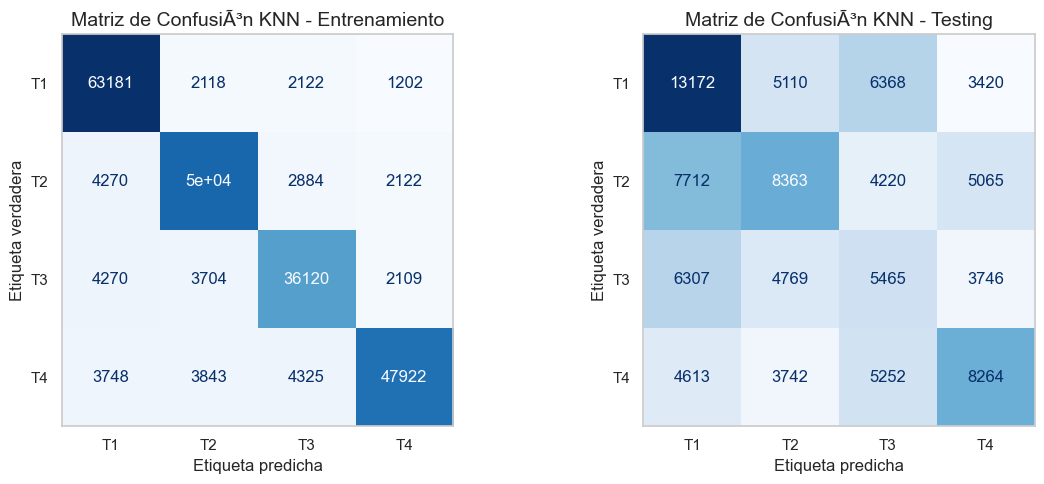

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

disp_train = ConfusionMatrixDisplay(confusion_matrix=knn_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión KNN - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

disp_test = ConfusionMatrixDisplay(confusion_matrix=knn_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión KNN - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.2 Predicciones con Random Forest

In [68]:
rf_prediction_test = make_prediction(rf_classifier, "test")

â±ï¸ RandomForestClassifier (test) predicho en 0.57s


In [69]:
rf_prediction_train = make_prediction(rf_classifier, "train")

â±ï¸ RandomForestClassifier (train) predicho en 1.38s


### 6.2.1 Guardar predicciones

In [ ]:
joblib.dump(rf_prediction_test, "results/predictions/frijol/test/predicciones_rf_test.pkl")
joblib.dump(rf_prediction_train, "results/predictions/frijol/train/predicciones_rf_train.pkl")

['results/predictions/frijol/train/predicciones_rf_train_v4.pkl']

### 6.2.2 Cargar predicciones

In [ ]:
rf_prediction_test = joblib.load("results/predictions/frijol/test/predicciones_rf_test.pkl")
rf_prediction_train = joblib.load("results/predictions/frijol/train/predicciones_rf_train.pkl")

### 6.2.3 Resultados

In [71]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, rf_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, rf_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     68623
           2       1.00      1.00      1.00     59593
           3       1.00      1.00      1.00     46203
           4       1.00      1.00      1.00     59838

    accuracy                           1.00    234257
   macro avg       1.00      1.00      1.00    234257
weighted avg       1.00      1.00      1.00    234257


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.45      0.44      0.45     28070
           2       0.42      0.38      0.40     25360
           3       0.26      0.28      0.27     20287
           4       0.42      0.46      0.44     21871

    accuracy                           0.39     95588
   macro avg       0.39      0.39      0.39     95588
weighted avg       0.40      0.39      0.39     95588



In [72]:
rf_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=rf_prediction_train,
    labels=None,
    normalize=None,
)

rf_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=rf_prediction_test,
    labels=None,
    normalize=None,
)

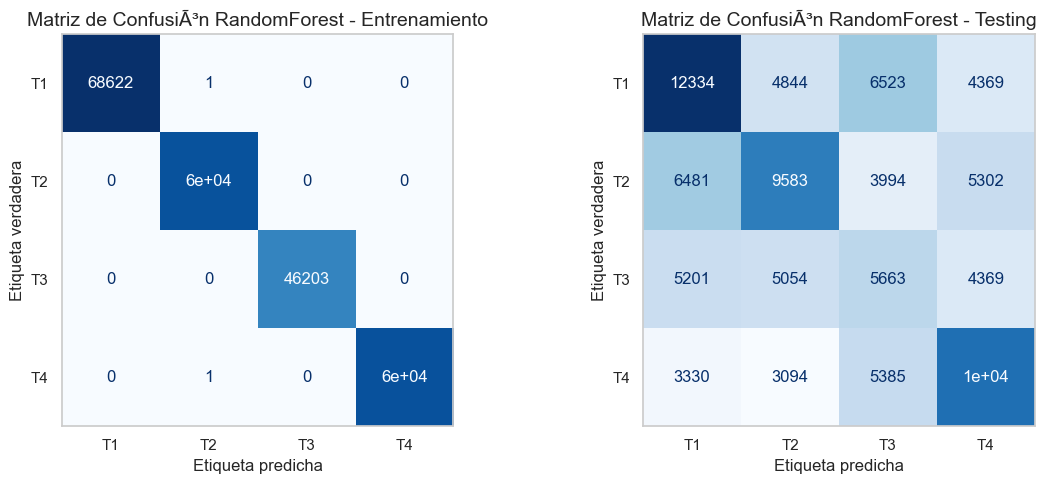

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=rf_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión RandomForest - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=rf_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión RandomForest - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.3 Predicciones con XGB

In [50]:
xgb_prediction_test = make_prediction(xgb_classifier, "test")

â±ï¸ XGBClassifier (test) predicho en 0.14s


In [51]:
xgb_prediction_train = make_prediction(xgb_classifier, "train")

â±ï¸ XGBClassifier (train) predicho en 0.33s


### 6.3.1 Guardar predicciones

In [ ]:
joblib.dump(xgb_prediction_test, "results/predictions/frijol/test/predicciones_xgb_test.pkl")
joblib.dump(xgb_prediction_train, "results/predictions/frijol/train/predicciones_xgb_train.pkl")

['results/predictions/frijol/train/predicciones_xgb_train_v4.pkl']

### 6.3.2 Cargar predicciones

In [ ]:
xgb_prediction_test = joblib.load("results/predictions/frijol/test/predicciones_xgb_test.pkl")
xgb_prediction_train = joblib.load("results/predictions/frijol/train/predicciones_xgb_train.pkl")

### 6.3.3 Resultados

In [53]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_encoded, xgb_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test_encoded, xgb_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           0       0.78      0.83      0.80     68623
           1       0.75      0.74      0.75     59593
           2       0.66      0.69      0.67     46203
           3       0.80      0.72      0.76     59838

    accuracy                           0.75    234257
   macro avg       0.75      0.75      0.75    234257
weighted avg       0.75      0.75      0.75    234257


Clasification Report - Prueba
              precision    recall  f1-score   support

           0       0.47      0.49      0.48     28070
           1       0.45      0.39      0.42     25360
           2       0.28      0.30      0.29     20287
           3       0.44      0.45      0.44     21871

    accuracy                           0.41     95588
   macro avg       0.41      0.41      0.41     95588
weighted avg       0.42      0.41      0.41     95588



In [54]:
xgb_cm_train = confusion_matrix(
    y_true=y_train_encoded,
    y_pred=xgb_prediction_train,
    labels=None,
    normalize=None,
)
xgb_cm_test = confusion_matrix(
    y_true=y_test_encoded,
    y_pred=xgb_prediction_test,
    labels=None,
    normalize=None,
)

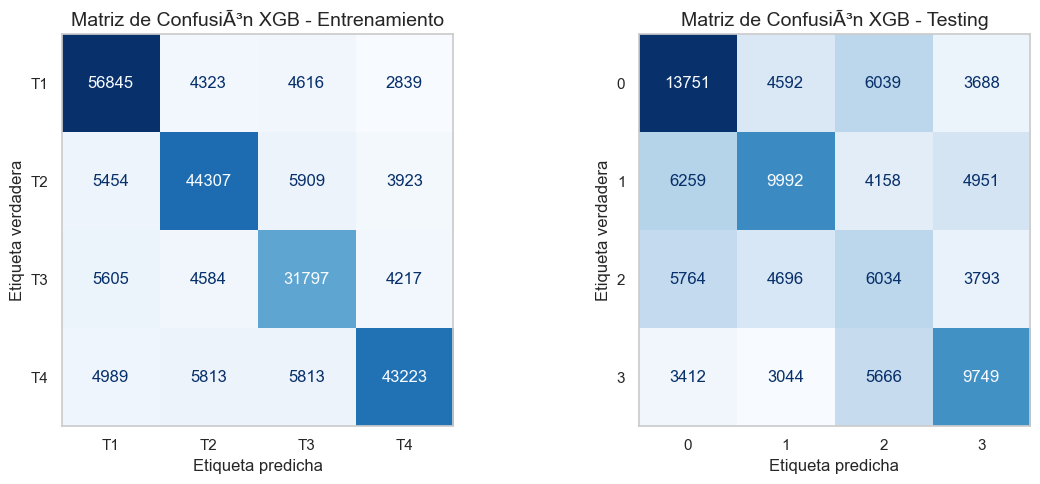

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión XGB - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_test)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión XGB - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.4 Predicciones con MLP

In [59]:
mlp_prediction_test = make_prediction(mlp_classifier, "test")

â±ï¸ MLPClassifier (test) predicho en 0.19s


In [60]:
mlp_prediction_train = make_prediction(mlp_classifier, "train")

â±ï¸ MLPClassifier (train) predicho en 0.47s


### 6.4.1 Guardar predicciones

In [ ]:
joblib.dump(mlp_prediction_test, "results/predictions/frijol/test/predicciones_mlp_test.pkl")
joblib.dump(mlp_prediction_train, "results/predictions/frijol/train/predicciones_mlp_train.pkl")

['results/predictions/frijol/train/predicciones_mlp_train_v4.pkl']

### 6.4.2 Cargar predicciones

In [ ]:
mlp_prediction_test = joblib.load("results/predictions/frijol/test/predicciones_mlp_test.pkl")
mlp_prediction_train = joblib.load("results/predictions/frijol/train/predicciones_mlp_train.pkl")

### 6.4.3 Resultados

In [62]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, mlp_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, mlp_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.70      0.76      0.73     68623
           2       0.72      0.57      0.63     59593
           3       0.49      0.56      0.52     46203
           4       0.67      0.66      0.67     59838

    accuracy                           0.65    234257
   macro avg       0.64      0.64      0.64    234257
weighted avg       0.65      0.65      0.65    234257


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.50      0.55      0.53     28070
           2       0.52      0.35      0.42     25360
           3       0.31      0.34      0.32     20287
           4       0.42      0.48      0.45     21871

    accuracy                           0.44     95588
   macro avg       0.44      0.43      0.43     95588
weighted avg       0.45      0.44      0.44     95588



In [63]:
mlp_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=mlp_prediction_train,
    labels=None,
    normalize=None,
)
mlp_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=mlp_prediction_test,
    labels=None,
    normalize=None,
)

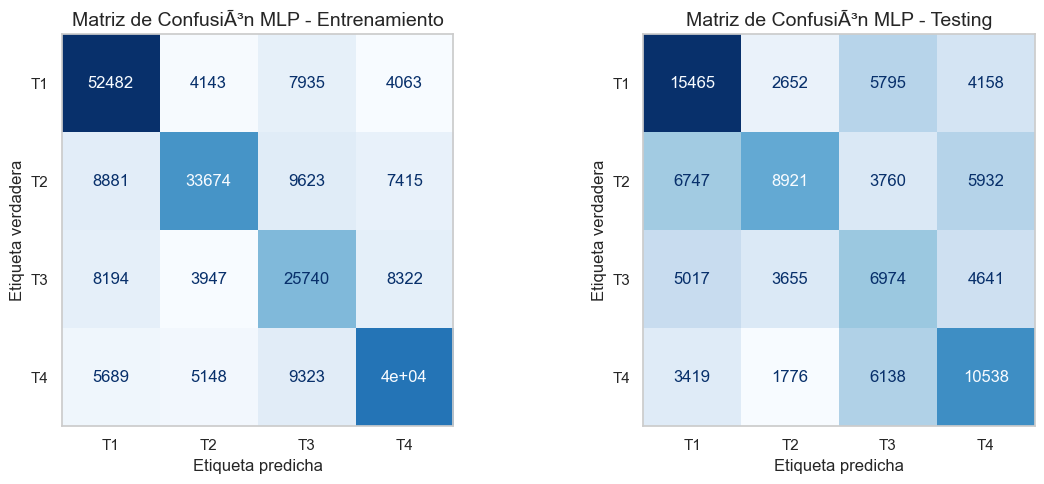

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión MLP - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión MLP - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

# 7. Evaluación del modelo

In [74]:
classifiers_names = ["knn", "rfc", "xgb", "mlp"]
predictions_train = [knn_prediction_train, rf_prediction_train, xgb_prediction_train, mlp_prediction_train]
predictions_test = [knn_prediction_test, rf_prediction_test, xgb_prediction_test, mlp_prediction_test]
cmxs_train = [knn_cm_train, rf_cm_train, xgb_cm_train, mlp_cm_train]
cmxs_test = [knn_cm_test, rf_cm_test, xgb_cm_test, mlp_cm_test]

## 7.1 Entrenamiento

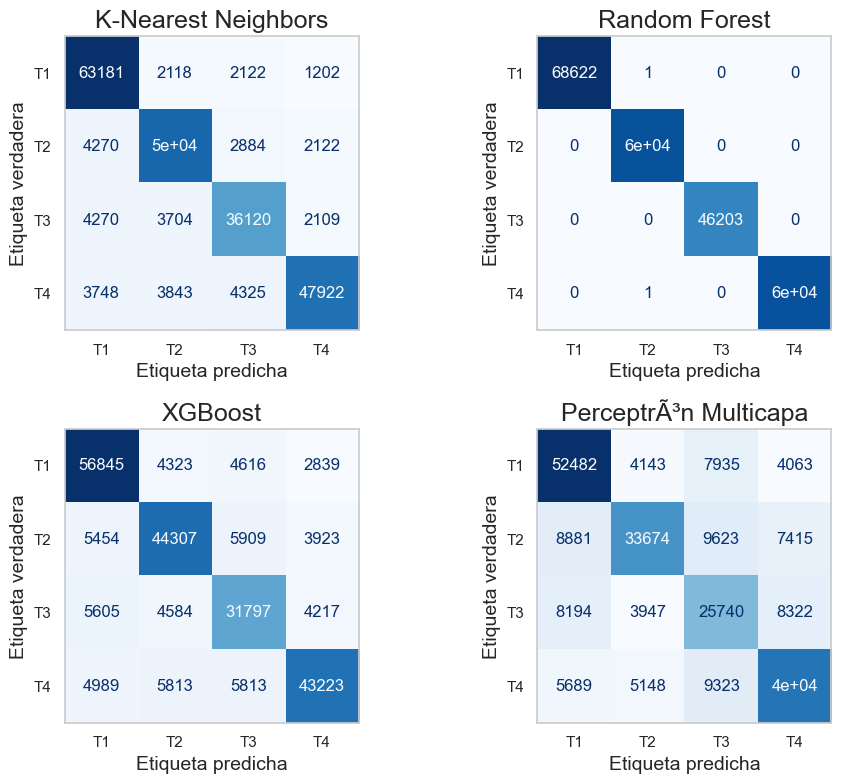

In [ ]:
num_models = 4
ncols = 2
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}

for i, (cm, classifier_name) in enumerate(zip(cmxs_train, classifiers_names)):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{classifier_display_names.get(classifier_name, classifier_name)}")
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')
    tick_positions = np.arange(cm.shape[0])
    tick_labels = tick_positions + 1

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
results_list = []

for preds, classifier_name in zip(predictions_train, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_train_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_train, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_train_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_train, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

print("Métricas - Entrenamiento")
display(results_df.style.background_gradient(cmap='summer_r', axis=0))

MÃ©tricas - Entrenamiento


,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.843262,0.844811,0.843262,0.842731,0.789342
rfc,0.999991,0.999991,0.999991,0.999991,0.999989
xgb,0.752046,0.753382,0.752046,0.751965,0.667228
mlp,0.647041,0.653803,0.647041,0.647218,0.526739


## 7.2 Testing

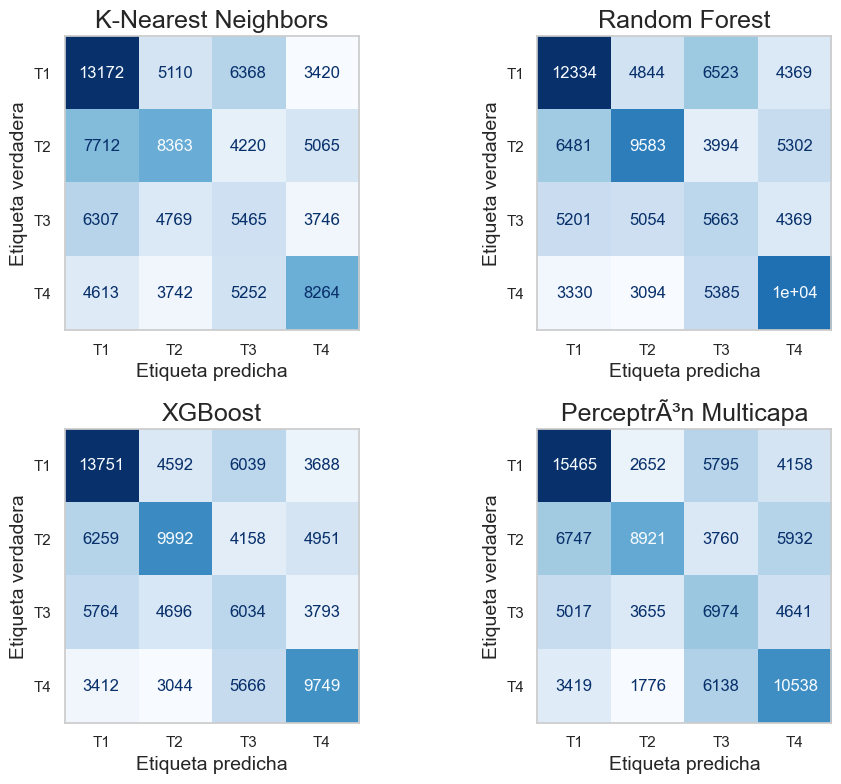

In [ ]:
num_models = 4
ncols = 2
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}

for i, (cm, classifier_name) in enumerate(zip(cmxs_test, classifiers_names)):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{classifier_display_names.get(classifier_name, classifier_name)}")
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')
    tick_positions = np.arange(cm.shape[0])
    tick_labels = tick_positions + 1

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [78]:
results_list = []

for preds, classifier_name in zip(predictions_test, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_test_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_test, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_test_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_test, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.368917,0.369246,0.368917,0.367970,0.152813
rfc,0.393794,0.396324,0.393794,0.394387,0.189305
xgb,0.413504,0.416152,0.413504,0.414228,0.214513
mlp,0.438319,0.448087,0.438319,0.437634,0.248927


In [119]:
# 7.3 Evaluación por objeto (voto mayoritario) en testing
if 'data_test' not in globals():
    raise ValueError("No existe 'data_test' en memoria. Ejecuta las celdas de preparación de datos.")

if 'object_id' not in data_test.columns:
    raise ValueError("La columna 'object_id' no está en data_test, no es posible evaluar por objeto.")

# Construir tabla base para evaluación a nivel de objeto
obj_eval_base = pd.DataFrame({
    'object_id': data_test['object_id'].reset_index(drop=True)
})

# y_test puede ser Series o array; normalizamos para que alinee por fila
if isinstance(y_test, pd.Series):
    y_test_px = y_test.reset_index(drop=True)
else:
    y_test_px = pd.Series(y_test, name='y_test')

if len(obj_eval_base) != len(y_test_px):
    raise ValueError(
        f"Desalineación entre object_id ({len(obj_eval_base)}) y y_test ({len(y_test_px)})."
    )

obj_eval_base['y_true_pixel'] = y_test_px.values

# Etiqueta real por objeto: mayoría de píxeles reales del mismo objeto
y_true_obj = (
    obj_eval_base
    .groupby('object_id')['y_true_pixel']
    .agg(lambda s: s.mode().iloc[0])
    .rename('y_true_obj')
)

object_results = []

for model_name, y_pred_px in zip(classifiers_names, predictions_test):
    pred_series = pd.Series(y_pred_px).reset_index(drop=True)

    if len(pred_series) != len(obj_eval_base):
        print(f"⚠️ {model_name}: tamaño de predicción no coincide con testing. Se omite.")
        continue

    # XGB puede estar codificado (0..n-1). Si aplica, lo decodificamos a etiquetas originales.
    if model_name == 'xgb' and 'le' in globals():
        try:
            pred_series = pd.Series(le.inverse_transform(pred_series.astype(int)))
        except Exception:
            pass

    pred_df = obj_eval_base[['object_id']].copy()
    pred_df['y_pred_pixel'] = pred_series.values

    # Predicción final por objeto mediante voto mayoritario
    y_pred_obj = (
        pred_df
        .groupby('object_id')['y_pred_pixel']
        .agg(lambda s: s.mode().iloc[0])
        .rename('y_pred_obj')
)

    comp = pd.concat([y_true_obj, y_pred_obj], axis=1).dropna()
    obj_acc = (comp['y_true_obj'] == comp['y_pred_obj']).mean()

    object_results.append({
        'Modelo': model_name,
        'Objetos evaluados': len(comp),
        'Accuracy (objeto - voto mayoritario)': obj_acc
    })

object_results_df = pd.DataFrame(object_results).set_index('Modelo').sort_values(
    by='Accuracy (objeto - voto mayoritario)', ascending=False
)

print("Métricas de testing a nivel de objeto (voto mayoritario):")
display(object_results_df.style.background_gradient(cmap='summer_r', axis=0))

Métricas de testing a nivel de objeto (voto mayoritario):


,Objetos evaluados,Accuracy (objeto - voto mayoritario)
Modelo,,
mlp,116,0.568966
xgb,116,0.551724
rfc,116,0.508621
knn,116,0.482759


# 8. Seleccionar hiperparámetros

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

def make_rand_grid_search(estimator, param_dist):
    # Usamos GroupKFold para no partir los pixeles de una misma hoja
    gkf = GroupKFold(n_splits=3)

    randomizedSearchCV = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=20,
        cv=gkf,
        scoring="f1_weighted",
        random_state=12,
        n_jobs=-1,
        refit=True
    )
    
    return randomizedSearchCV

### 8.0.1 Guardar progreso

In [ ]:
# Crear directorios para guardar modelos por etapa
for stage_dir in ['hyperparameter_tuning', 'best']:
    os.makedirs(f'models/frijol/{stage_dir}', exist_ok=True)

# Función para guardar progreso
def save_model_and_params(model, model_name, best_params, score, stage="hyperparameter_tuning"):
    """
    Guarda el modelo, sus mejores parámetros y el score obtenido
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Crear diccionario con toda la información
    model_info = {
        'model': model,
        'best_params': best_params,
        'best_score': score,
        'timestamp': timestamp,
        'model_name': model_name,
        'stage': stage
    }
    
    # Guardar en el directorio correspondiente
    save_path = f'models/frijol/{stage}/{model_name}_{timestamp}.pkl'
    
    # with open(save_path, 'wb') as f:
    #     pickle.dump(model_info, f)
    joblib.dump(model_info, save_path, compress=3)
    
    print(f"✅ Modelo {model_name} guardado en: {save_path}")
    return save_path

In [ ]:
# Función para cargar modelo guardado
def load_model_info(filepath):
    """
    Carga un modelo guardado y su información
    """
    # with open(filepath, 'rb') as f:
    #     model_info = pickle.load(f)

    model_info = joblib.load(filepath)
    
    print(f"✅ Modelo {model_info['model_name']} cargado desde: {filepath}")
    print(f"   - Score: {model_info['best_score']:.4f}")
    print(f"   - Timestamp: {model_info['timestamp']}")
    
    return model_info

### 8.0.2 Recuperación de progreso

Cargar modelos previamente guardados.

In [ ]:
# Función para listar modelos guardados
def list_saved_models(stage="all"):
    """
    Lista todos los modelos guardados
    stage: 'hyperparameter_tuning', 'best', o 'all'
    """
    stages_to_check = []
    if stage == "all":
        stages_to_check = ["hyperparameter_tuning", "best"]
    else:
        stages_to_check = [stage]
    
    all_models = {}
    
    for stage_name in stages_to_check:
        path = f'models/frijol/{stage_name}'
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if f.endswith('.pkl')]
            if files:
                all_models[stage_name] = files
                print(f"\nðŸ“ Modelos en {stage_name}:")
                for i, file in enumerate(files, 1):
                    print(f"  {i}. {file}")
    
    if not all_models:
        print("No se encontraron modelos guardados")
    
    return all_models

# Funciíón para cargar el modelo más reciente de un tipo específico
def load_latest_model(model_name, stage="best"):
    """
    Carga el modelo más reciente de un tipo especí­fico
    """
    path = f'models/frijol/{stage}'
    if not os.path.exists(path):
        print(f"âŒ Directorio {path} no existe")
        return None
    
    # Buscar archivos que coincidan con el nombre del modelo
    files = [f for f in os.listdir(path) if f.startswith(model_name) and f.endswith('.pkl')]
    
    if not files:
        print(f"No se encontraron modelos de tipo {model_name} en {stage}")
        return None
    
    # Ordenar por fecha (timestamp en el nombre del archivo)
    files.sort(reverse=True)  # Más reciente primero
    latest_file = files[0]
    
    return load_model_info(os.path.join(path, latest_file))

In [ ]:
# Si se necesita recuperar progreso
print("🔎 Buscando modelos guardados...")
saved_models = list_saved_models()

ðŸ” Buscando modelos guardados...

ðŸ“ Modelos en hyperparameter_tuning:
  1. KNN_20251008_171051.pkl
  2. KNN_2_20251028_220337.pkl
  3. MLP_20251014_085414.pkl
  4. XGBoost_20251008_171837.pkl
  5. XGBoost_2_20251028_221907.pkl

ðŸ“ Modelos en best:
  1. KNN_final_20251030_183420.pkl
  2. KNN_final_2_20251028_220611.pkl
  3. MLP_final_20251017_112954.pkl
  4. RandomForest_final_2_20251028_225448.pkl
  5. XGBoost_final_20251008_172140.pkl
  6. XGBoost_final_2_20251028_222112.pkl


In [ ]:
# Para cargar un modelo especí­fico:
model_info = load_latest_model("KNN_final", "best")
knn_final = model_info['model']

## 8.1 Selección de muestra

Para acelerar la búsqueda de hiperparámetros, se trabaja con una muestra representativa del dataset de entrenamiento. Una vez encontrados los mejores parámetros, se entrena con el dataset completo.

In [ ]:
# Configuración del tamaño de muestra para hiperparámetros
HYPERPARAMETER_SAMPLE_SIZE = 0.6  # 15% del dataset de entrenamiento
RANDOM_STATE = 42

print(f"Dataset original de entrenamiento: {X_train_scaled.shape[0]:,} muestras")

# Crear muestra estratificada manteniendo la proporción de clases
X_train_sample, _, y_train_sample, _, groups_sample, _ = train_test_split(
    X_train_scaled, 
    y_train,
    data_train['object_id'],           # Object id paralelo al split
    test_size=1-HYPERPARAMETER_SAMPLE_SIZE,
    stratify=y_train,                # Mantiene proporción de las clases sanas/enfermas
    random_state=RANDOM_STATE
)

# Para XGBoost versión codificada
y_train_sample_encoded = le.transform(y_train_sample)

print(f"Muestra para hiperparámetros: {X_train_sample.shape[0]:,} muestras ({HYPERPARAMETER_SAMPLE_SIZE*100:.1f}%)")
print(f"Reducción de tiempo estimada: ~{(1/HYPERPARAMETER_SAMPLE_SIZE):.1f}x más rápido")

# Verificar distribución de clases en la muestra
print("\nDistribución de clases en muestra para hiperparámetros:")
print(pd.Series(y_train_sample).value_counts().sort_index())

Dataset original de entrenamiento: 234,257 muestras
Muestra para hiperparÃ¡metros: 140,554 muestras (60.0%)
ReducciÃ³n de tiempo estimada: ~1.7x mÃ¡s rÃ¡pido

DistribuciÃ³n de clases en muestra para hiperparÃ¡metros:
tratamiento
1    41173
2    35756
3    27722
4    35903
Name: count, dtype: int64


## 8.2 KNeighbors - Búsqueda de hiperparámetros

In [ ]:
knn_param_grid = {
    'n_neighbors': [15, 30, 50, 100],     # Grupos más grandes suavizan la decisión
    'weights': ['uniform', 'distance'],
    'p': [1, 2]                           # 1 = Distancia Manhattan, 2 = Euclidiana
}

In [ ]:
print("✅ Iniciando búsqueda de hiperparámetros para KNN con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros
    knn_gridSearchCV = make_rand_grid_search(KNeighborsClassifier(n_jobs=-1), knn_param_grid)
    knn_gridSearchCV.fit(X_train_sample, y_train_sample, groups=groups_sample)
    search_elapsed = time.time() - search_start
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=knn_gridSearchCV,
        model_name="KNN",
        best_params=knn_gridSearchCV.best_params_,
        score=knn_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros KNN completada exitosamente")
    print(f"Best Score: {knn_gridSearchCV.best_score_:.4f}")
    print(f"🕓 Tiempo búqueda KNN: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros KNN: {e}")
    raise

✅ Iniciando búsqueda de hiperparámetros para KNN con muestra reducida...
Muestra: 140,554 registros
✅ Modelo KNN guardado en: models/frijol/hyperparameter_tuning/KNN_20260418_193736_v4.pkl
✅ Búsqueda de hiperparámetros KNN completada exitosamente
Best Score: 0.3942
🕓 Tiempo búqueda KNN: 649.76 s (10.83 min)


In [105]:
print("🎯 Mejores parámetros encontrados para KNN:")
print(knn_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {knn_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para KNN:
{'weights': 'uniform', 'p': 1, 'n_neighbors': 100}
Score de validación cruzada: 0.3942


In [ ]:
# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando KNN con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
knn_final = KNeighborsClassifier(n_jobs=-1, **knn_gridSearchCV.best_params_)
train_start = time.time()
knn_final.fit(X_train_scaled, y_train)
train_elapsed = time.time() - train_start

print(f"🕓 Tiempo entrenamiento KNN final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=knn_final,
    model_name="KNN_final",
    best_params=knn_gridSearchCV.best_params_,
    score=knn_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo KNN final entrenado y guardado")


🚀 Entrenando KNN con dataset completo (234,257 muestras)...
🕓 Tiempo entrenamiento KNN final: 0.58 s (0.01 min)
✅ Modelo KNN_final guardado en: models/frijol/best/KNN_final_20260418_210148_v4.pkl
✅ Modelo KNN final entrenado y guardado


### 8.2.1 Predicciones

In [107]:
# Usar modelo final para predicciones
knn_y_train_pred = knn_final.predict(X_train_scaled)
knn_y_test_pred = knn_final.predict(X_test_scaled)

#### Guardar predicciones

In [ ]:
joblib.dump(knn_y_test_pred, "results/predictions/frijol/test/best_predicciones_knn_test.pkl")

['results/predictions/frijol/test/best_predicciones_knn_test_v4.pkl']

In [ ]:
joblib.dump(knn_y_train_pred, "results/predictions/frijol/train/best_predicciones_knn_train.pkl")

['results/predictions/frijol/train/best_predicciones_knn_train_v4.pkl']

#### Cargar predicciones

In [ ]:
knn_y_test_pred = joblib.load('results/predictions/frijol/test/best_predicciones_knn_test".pkl')

In [ ]:
knn_y_train_pred = joblib.load('results/predictions/frijol/train/best_predicciones_knn_train.pkl')

### 8.2.2 Resultados

In [110]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, knn_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, knn_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.74      0.84      0.79     68623
           2       0.74      0.72      0.73     59593
           3       0.64      0.65      0.64     46203
           4       0.80      0.68      0.74     59838

    accuracy                           0.73    234257
   macro avg       0.73      0.72      0.72    234257
weighted avg       0.73      0.73      0.73    234257


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.43      0.49      0.45     28070
           2       0.42      0.36      0.39     25360
           3       0.26      0.29      0.28     20287
           4       0.44      0.39      0.42     21871

    accuracy                           0.39     95588
   macro avg       0.39      0.38      0.38     95588
weighted avg       0.39      0.39      0.39     95588



In [111]:
knn_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=knn_y_train_pred,
    labels=None,
    normalize=None,
)

In [112]:
knn_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=knn_y_test_pred,
    labels=None,
    normalize=None,
)

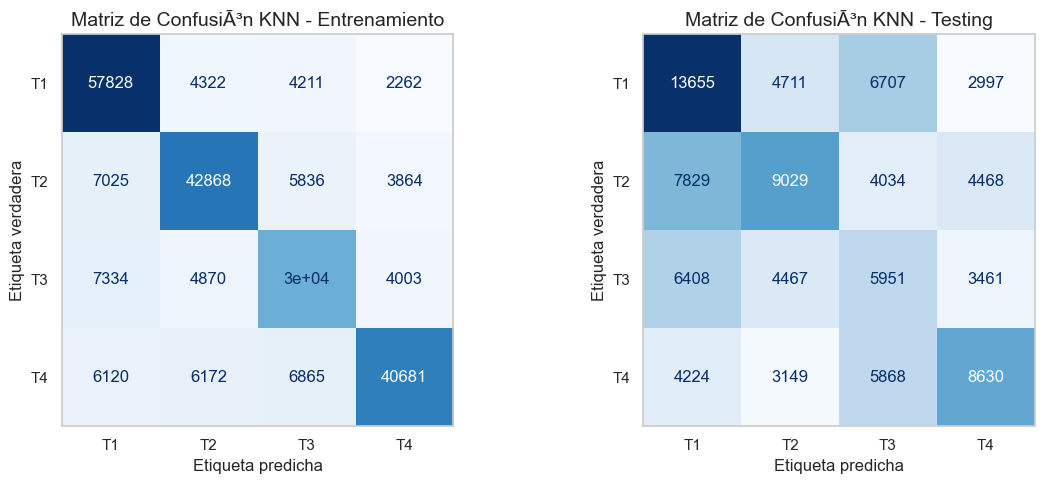

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

disp_train = ConfusionMatrixDisplay(confusion_matrix=knn_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión KNN - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

disp_test = ConfusionMatrixDisplay(confusion_matrix=knn_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión KNN - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 8.3 Random Forest - Búsqueda de hiperparámetros

In [ ]:
# Hiperparámetros que permiten mayor regularización
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],             # Limita la profundidad máxima drásticamente
    'min_samples_split': [20, 50, 100],   # Requiere más muestras para crear una nueva rama
    'min_samples_leaf': [10, 20, 50],     # Requiere más muestras en los nodos finales
    'max_features': ['sqrt', 'log2']      # Usa solo un subconjunto de bandas por división
}

In [128]:
print("✅ Iniciando búsqueda de hiperparámetros para Random Forest con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros
    rf_gridSearchCV = make_rand_grid_search(RandomForestClassifier(n_jobs=-1, random_state=12), rf_param_grid)
    rf_gridSearchCV.fit(X_train_sample, y_train_sample, groups=groups_sample)
    search_elapsed = time.time() - search_start
    
    print(f"🕓 Tiempo búsqueda Random Forest: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")

    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=rf_gridSearchCV,
        model_name="RandomForest",
        best_params=rf_gridSearchCV.best_params_,
        score=rf_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros Random Forest completada exitosamente")
    print(f"Best Score: {rf_gridSearchCV.best_score_:.4f}")
       
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros Random Forest: {e}")
    raise

✅ Iniciando búsqueda de hiperparámetros para Random Forest con muestra reducida...
Muestra: 140,554 registros
✅ Modelo RandomForest guardado en: models/frijol/hyperparameter_tuning/RandomForest_20260418_212747_v4.pkl
✅ Búsqueda de hiperparámetros Random Forest completada exitosamente
Best Score: 0.4062
🕓 Tiempo búsqueda Random Forest: 533.23 s (8.89 min)


In [129]:
print("🎯 Mejores parámetros encontrados para Random Forest:")
print(rf_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {rf_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para Random Forest:
{'n_estimators': 100, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'log2', 'max_depth': 15}
Score de validación cruzada: 0.4062


In [ ]:
# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando Random Forest con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
rf_final = RandomForestClassifier(n_jobs=-1, random_state=12, **rf_gridSearchCV.best_params_)
train_start = time.time()
rf_final.fit(X_train_scaled, y_train)
train_elapsed = time.time() - train_start

print(f"🕓 Tiempo entrenamiento Random Forest final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=rf_final,
    model_name="RandomForest_final",
    best_params=rf_gridSearchCV.best_params_,
    score=rf_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo Random Forest final entrenado y guardado")


🚀 Entrenando Random Forest con dataset completo (234,257 muestras)...
🕓 Tiempo entrenamiento Random Forest final: 7.60 s (0.13 min)
✅ Modelo RandomForest_final guardado en: models/frijol/best/RandomForest_final_20260418_212820_v4.pkl
✅ Modelo Random Forest final entrenado y guardado


### 8.3.1 Predicciones

In [131]:
# Usar modelo final para predicciones
rf_y_train_pred = rf_final.predict(X_train_scaled)
rf_y_test_pred = rf_final.predict(X_test_scaled)

#### Guardar predicciones

In [ ]:
joblib.dump(rf_y_test_pred, "results/predictions/frijol/test/best_predicciones_rf_test.pkl")

['results/predictions/frijol/test/best_predicciones_rf_test_v4.pkl']

In [ ]:
joblib.dump(rf_y_train_pred, "results/predictions/frijol/train/best_predicciones_rf_train.pkl")

['results/predictions/frijol/train/best_predicciones_rf_train_v4.pkl']

#### Cargar predicciones

In [38]:
rf_y_test_pred = joblib.load('results/predictions/frijol/test/best_predicciones_rf_test_fix.pkl')

In [39]:
rf_y_train_pred = joblib.load('results/predictions/frijol/train/best_predicciones_rf_train_fix.pkl')

### 8.3.2 Resultados

In [134]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, rf_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, rf_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.74      0.82      0.78     68623
           2       0.72      0.70      0.71     59593
           3       0.61      0.62      0.62     46203
           4       0.77      0.68      0.72     59838

    accuracy                           0.71    234257
   macro avg       0.71      0.71      0.71    234257
weighted avg       0.72      0.71      0.71    234257


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.47      0.52      0.49     28070
           2       0.47      0.41      0.44     25360
           3       0.30      0.31      0.30     20287
           4       0.49      0.47      0.48     21871

    accuracy                           0.44     95588
   macro avg       0.43      0.43      0.43     95588
weighted avg       0.44      0.44      0.44     95588



In [135]:
rf_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=rf_y_train_pred,
    labels=None,
    normalize=None,
)

In [136]:
rf_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=rf_y_test_pred,
    labels=None,
    normalize=None,
)

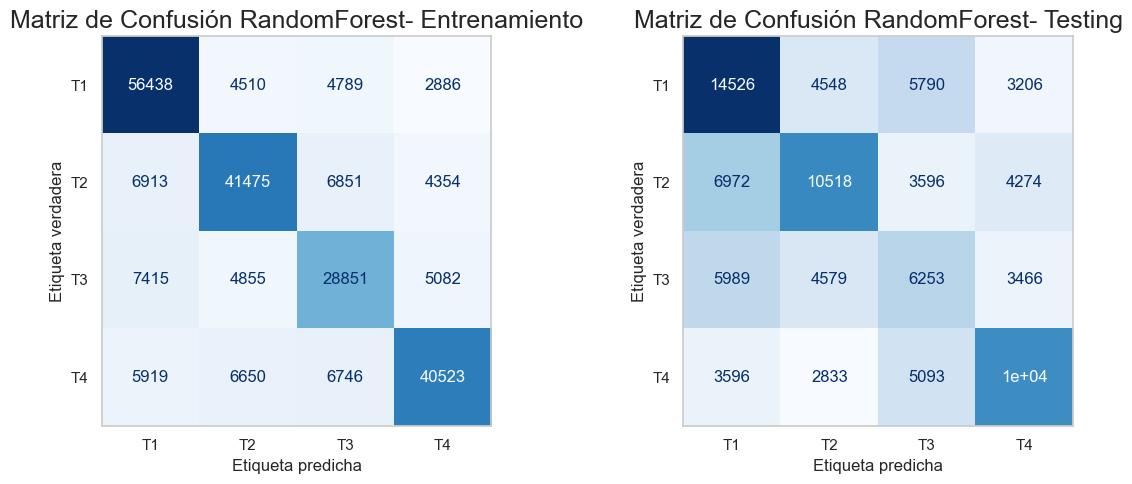

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=rf_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión RandomForest- Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=rf_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión RandomForest- Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 8.4 XGB - Búsqueda de hiperparámetros

In [ ]:
# Hieprparámetros que permiten mayor regularización
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],               # Árboles enanos obligan a buscar patrones fuertes
    'learning_rate': [0.01, 0.05, 0.1],   # Aprendizaje más lento
    'subsample': [0.6, 0.8],              # Usa solo un % de los píxeles en cada árbol
    'colsample_bytree': [0.6, 0.8],       # Usa solo un % de las bandas en cada árbol
    'reg_lambda': [1, 10, 50],            # Regularización L2: penaliza pesos altos
    'gamma': [0, 1, 5]                    # Requiere una ganancia mínima de pérdida para dividir
}

In [ ]:
print("✅ Iniciando búsqueda de hiperparámetros para XGBoost con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros
    xgb_gridSearchCV = make_rand_grid_search(xgb.XGBClassifier(random_state=42), xgb_param_grid)
    xgb_gridSearchCV.fit(X_train_sample, y_train_sample_encoded, groups=groups_sample)
    search_elapsed = time.time() - search_start
    
    print(f"🕓 Tiempo búsqueda XGB: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")

    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=xgb_gridSearchCV,
        model_name="XGBoost",
        best_params=xgb_gridSearchCV.best_params_,
        score=xgb_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros XGBoost completada exitosamente")
    print(f"Best Score: {xgb_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros XGBoost: {e}")
    raise

✅ Iniciando búsqueda de hiperparámetros para XGBoost con muestra reducida...
Muestra: 140,554 registros
🕓 Tiempo búsqueda XGB: 307.83 s (5.13 min)
✅ Modelo XGBoost guardado en: models/frijol/hyperparameter_tuning/XGBoost_20260418_211340_v4.pkl
✅ Búsqueda de hiperparÃ¡metros XGBoost completada exitosamente
Best Score: 0.4126


In [117]:
print("🎯 Mejores parámetros encontrados para XGB:")
print(xgb_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {xgb_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para XGB:
{'subsample': 0.8, 'reg_lambda': 50, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}
Score de validación cruzada: 0.4126


In [ ]:
print(f"\n🚀 Entrenando XGBoost con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
xgb_final = xgb.XGBClassifier(random_state=42, **xgb_gridSearchCV.best_params_)
train_start = time.time()
xgb_final.fit(X_train_scaled, y_train_encoded)
train_elapsed = time.time() - train_start

print(f"🕓 Tiempo entrenamiento XGB final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=xgb_final,
    model_name="XGBoost_final",
    best_params=xgb_gridSearchCV.best_params_,
    score=xgb_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo XGBoost final entrenado y guardado")


🚀 Entrenando XGBoost con dataset completo (234,257 muestras)...
🕓 Tiempo entrenamiento XGB final: 6.24 s (0.10 min)
✅ Modelo XGBoost_final guardado en: models/frijol/best/XGBoost_final_20260418_211411_v4.pkl
✅ Modelo XGBoost final entrenado y guardado


### 8.4.1 Predicciones

In [120]:
# Usar modelo final para predicciones
xgb_y_train_pred = xgb_final.predict(X_train_scaled)
xgb_y_test_pred = xgb_final.predict(X_test_scaled)

#### Guardar predicciones

In [ ]:
joblib.dump(xgb_y_test_pred, "results/predictions/frijol/test/best_predicciones_xgb_test.pkl")

['results/predictions/frijol/test/best_predicciones_xgb_test_v4.pkl']

In [ ]:
joblib.dump(xgb_y_train_pred, "results/predictions/frijol/train/best_predicciones_xgb_train.pkl")

['results/predictions/frijol/train/best_predicciones_xgb_train_v4.pkl']

#### Cargar predicciones

In [ ]:
xgb_y_test_pred = joblib.load('results/predictions/frijol/test/best_predicciones_xgb_test.pkl')

In [ ]:
xgb_y_train_pred = joblib.load('results/predictions/frijol/train/best_predicciones_xgb_train.pkl')

### 8.4.2 Resultados

In [123]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_encoded, xgb_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test_encoded, xgb_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           0       0.70      0.76      0.73     68623
           1       0.68      0.69      0.68     59593
           2       0.55      0.59      0.57     46203
           3       0.73      0.61      0.67     59838

    accuracy                           0.67    234257
   macro avg       0.67      0.66      0.66    234257
weighted avg       0.67      0.67      0.67    234257


Clasification Report - Prueba
              precision    recall  f1-score   support

           0       0.47      0.51      0.49     28070
           1       0.47      0.42      0.44     25360
           2       0.29      0.33      0.31     20287
           3       0.49      0.44      0.46     21871

    accuracy                           0.43     95588
   macro avg       0.43      0.43      0.43     95588
weighted avg       0.44      0.43      0.43     95588



In [124]:
xgb_cm_train = confusion_matrix(
    y_true=y_train_encoded,
    y_pred=xgb_y_train_pred,
    labels=None,
    normalize=None,
)

xgb_cm_test = confusion_matrix(
    y_true=y_test_encoded,
    y_pred=xgb_y_test_pred,
    labels=None,
    normalize=None,
)

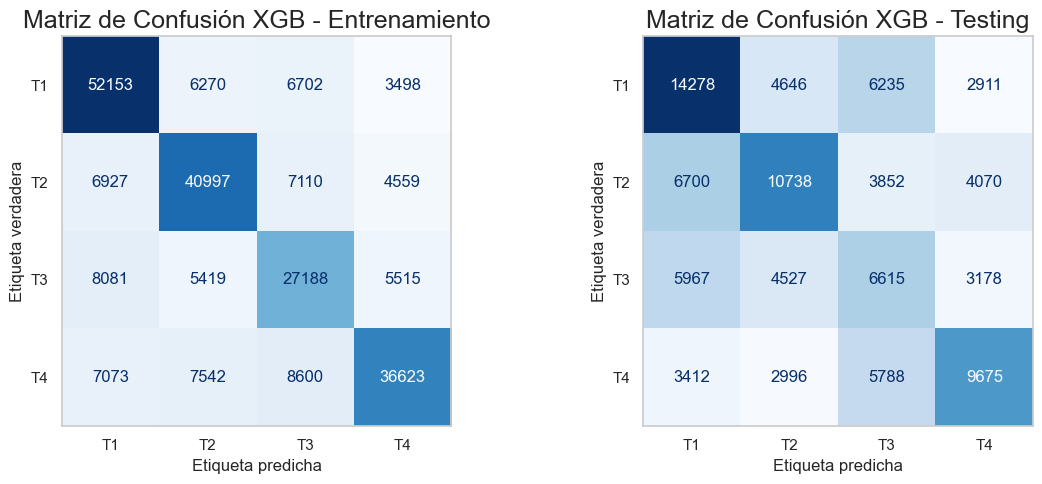

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión XGB - Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión XGB - Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 8.5 MLP - Búsqueda de hiperparámetros

In [ ]:
# Hiperparametros que permiten mayor regularización
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)], 
    'alpha': [0.001, 0.01, 0.1, 1.0],     # Regularización L2 (vital para evitar sobreajuste)
    'activation': ['relu', 'tanh'],
    'early_stopping': [True],             # Detiene el entrenamiento si no mejora
    'validation_fraction': [0.1],         # % de datos usados para early_stopping
    'n_iter_no_change': [10]              # Épocas de paciencia
}

In [ ]:
print("✅ Iniciando búsqueda de hiperparámetros para MLP con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros
    mlp_gridSearchCV = make_rand_grid_search(MLPClassifier(), mlp_param_grid)
    mlp_gridSearchCV.fit(X_train_sample, y_train_sample, groups=groups_sample)
    search_elapsed = time.time() - search_start
    
    print(f"🕓 Tiempo búsqueda MLP: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=mlp_gridSearchCV,
        model_name="MLP",
        best_params=mlp_gridSearchCV.best_params_,
        score=mlp_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros MLP completada exitosamente")
    print(f"Best Score: {mlp_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error during MLP hyperparameter search: {e}")
    raise

✅ Iniciando búsqueda de hiperparámetros para MLP con muestra reducida...
Muestra: 140,554 registros
🕓 Tiempo búsqueda MLP: 1268.51 s (21.14 min)
✅ Modelo MLP guardado en: models/frijol/hyperparameter_tuning/MLP_20260418_215317_v4.pkl
✅ Búsqueda de hiperparámetros MLP completada exitosamente
Best Score: 0.4558


In [142]:
print("🎯 Mejores parámetros encontrados para MLP:")
print(mlp_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {mlp_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para MLP:
{'validation_fraction': 0.1, 'n_iter_no_change': 10, 'hidden_layer_sizes': (100,), 'early_stopping': True, 'alpha': 0.01, 'activation': 'relu'}
Score de validación cruzada: 0.4558


In [143]:
# Entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando MLP con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
mlp_final = MLPClassifier(**mlp_gridSearchCV.best_params_)
train_start = time.time()
mlp_final.fit(X_train_scaled, y_train)
train_elapsed = time.time() - train_start

print(f"🕓 Tiempo entrenamiento MLP final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=mlp_final,
    model_name="MLP_final",
    best_params=mlp_gridSearchCV.best_params_,
    score=mlp_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo MLP final entrenado y guardado")


🚀 Entrenando MLP con dataset completo (234,257 muestras)...
🕓 Tiempo entrenamiento MLP final: 249.56 s (4.16 min)
✅ Modelo MLP_final guardado en: models/frijol/best/MLP_final_20260418_215727_v4.pkl
✅ Modelo MLP final entrenado y guardado


### 8.5.1 Predicciones

In [144]:
# Usar modelo final para predicciones
mlp_y_test_pred = mlp_final.predict(X_test_scaled)

In [145]:
mlp_y_train_pred = mlp_final.predict(X_train_scaled)

#### Guardar predicciones

In [ ]:
joblib.dump(mlp_y_test_pred, "results/predictions/frijol/test/best_predicciones_mlp_test.pkl")

['results/predictions/frijol/test/best_predicciones_mlp_test_v4.pkl']

In [ ]:
joblib.dump(mlp_y_train_pred, "results/predictions/frijol/train/best_predicciones_mlp_train.pkl")

['results/predictions/frijol/train/best_predicciones_mlp_train_v4.pkl']

#### Cargar predicciones

In [ ]:
mlp_y_test_pred = joblib.load('results/predictions/frijol/test/best_predicciones_mlp_test.pkl')

In [ ]:
mlp_y_train_pred = joblib.load('results/predictions/frijol/train/best_predicciones_mlp_train.pkl')

### 8.5.2 Resultados

In [148]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train, mlp_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, mlp_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.69      0.74      0.71     68623
           2       0.66      0.61      0.64     59593
           3       0.48      0.57      0.52     46203
           4       0.71      0.59      0.64     59838

    accuracy                           0.64    234257
   macro avg       0.63      0.63      0.63    234257
weighted avg       0.64      0.64      0.64    234257


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.52      0.53      0.53     28070
           2       0.48      0.41      0.44     25360
           3       0.30      0.33      0.32     20287
           4       0.44      0.45      0.44     21871

    accuracy                           0.44     95588
   macro avg       0.43      0.43      0.43     95588
weighted avg       0.44      0.44      0.44     95588



In [149]:
mlp_cm_train = confusion_matrix(
    y_true=y_train,
    y_pred=mlp_y_train_pred,
    labels=None,
    normalize=None,
)

mlp_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=mlp_y_test_pred,
    labels=None,
    normalize=None,
)

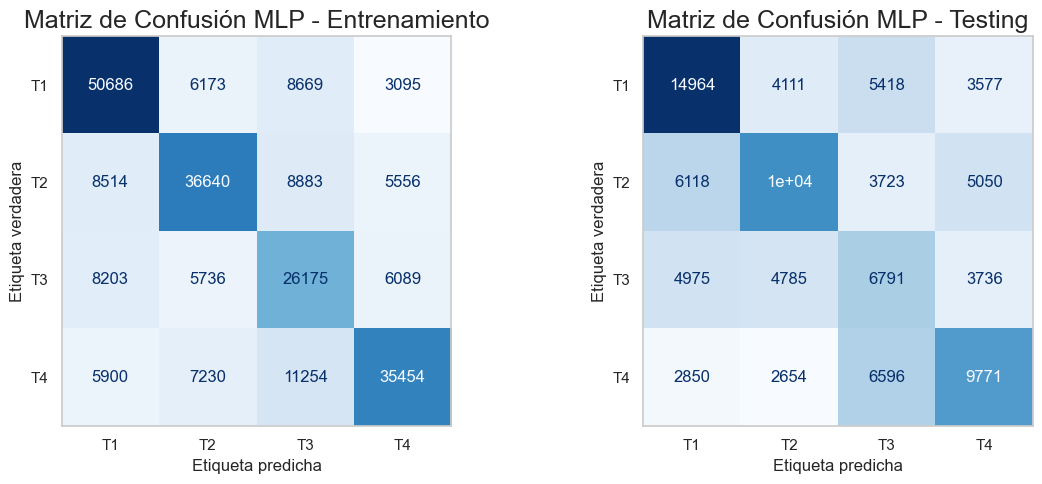

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión MLP - Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión MLP - Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 8.6. Comparación final de modelos optimizados

Después de la búsqueda de hiperparámetros y entrenamiento con el dataset completo se compara el rendimiento de todos los modelos optimizados.

In [151]:
# Compilar resultados de todos los modelos optimizados
final_models = [
    ('KNN Optimizado', knn_y_train_pred, knn_y_test_pred),
    ('Random Forest Optimizado', rf_y_train_pred, rf_y_test_pred),
    ('XGBoost Optimizado', xgb_y_train_pred, xgb_y_test_pred),
    ('MLP Optimizado', mlp_y_train_pred, mlp_y_test_pred)
]

In [152]:
final_results = []

for model_name, train_pred, test_pred in final_models:
    # Para XGBoost usamos las versiones encoded
    if 'XGBoost' in model_name:
        train_report = classification_report(y_train_encoded, train_pred, output_dict=True)
        test_report = classification_report(y_test_encoded, test_pred, output_dict=True)
        train_kappa = cohen_kappa_score(y_train_encoded, train_pred)
        test_kappa = cohen_kappa_score(y_test_encoded, test_pred)
    else:
        train_report = classification_report(y_train, train_pred, output_dict=True)
        test_report = classification_report(y_test, test_pred, output_dict=True)
        train_kappa = cohen_kappa_score(y_train, train_pred)
        test_kappa = cohen_kappa_score(y_test, test_pred)
    
    final_results.append({
        'Modelo': model_name,
        'Train Accuracy': train_report['accuracy'],
        'Test Accuracy': test_report['accuracy'],
        'Train Precision': train_report['weighted avg']['precision'],
        'Test Precision': test_report['weighted avg']['precision'],
        'Train Recall': train_report['weighted avg']['recall'],
        'Test Recall': test_report['weighted avg']['recall'],
        'Train F1-Score': train_report['weighted avg']['f1-score'],
        'Test F1-Score': test_report['weighted avg']['f1-score'],
        'Train Kappa': train_kappa,
        'Test Kappa': test_kappa,
        'Overfitting': abs(train_report['accuracy'] - test_report['accuracy'])
    })

final_results_df = pd.DataFrame(final_results)
final_results_df = final_results_df.set_index('Modelo')

print("🎯 RESULTADOS FINALES - MODELOS OPTIMIZADOS")
print("=" * 60)
display(final_results_df.style.background_gradient(cmap='RdYlGn', axis=0).format(precision=4))

# Encontrar el mejor modelo
best_model_idx = final_results_df['Test Accuracy'].idxmax()
best_score = final_results_df.loc[best_model_idx, 'Test Accuracy']

print(f"\n🎯 MEJOR MODELO: {best_model_idx}")
print(f"   Test Accuracy: {best_score:.4f}")
print(f"   Test F1-Score: {final_results_df.loc[best_model_idx, 'Test F1-Score']:.4f}")
print(f"   Overfitting: {final_results_df.loc[best_model_idx, 'Overfitting']:.4f}")

🎯 RESULTADOS FINALES - MODELOS OPTIMIZADOS


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1-Score,Test F1-Score,Train Kappa,Test Kappa,Overfitting
Modelo,,,,,,,,,,,
KNN Optimizado,0.7316,0.3899,0.7342,0.3940,0.7316,0.3899,0.7306,0.3901,0.6392,0.1812,0.3417
Random Forest Optimizado,0.7141,0.4357,0.7155,0.4366,0.7141,0.4357,0.7133,0.4353,0.6159,0.2426,0.2784
XGBoost Optimizado,0.6700,0.4321,0.6735,0.4365,0.6700,0.4321,0.6700,0.4334,0.5573,0.2385,0.2379
MLP Optimizado,0.6359,0.4393,0.6440,0.4431,0.6359,0.4393,0.6375,0.4404,0.5124,0.2495,0.1965



🎯 MEJOR MODELO: MLP Optimizado
   Test Accuracy: 0.4393
   Test F1-Score: 0.4404
   Overfitting: 0.1965
